In [1]:
# install.packages("tidyverse")
library(tidyverse)

# install.packages("corrplot")
library(corrplot)

# install.packages("moments")
library(moments)

# install.packages("car")
library(car)

# install.packages("lmtest")
library(lmtest)

# install.packages("tseries")
library(tseries)

# install.packages("strucchange")
library(strucchange) # para o chow test

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


The following object is masked from 'package:purrr':

    some


Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading require

In [2]:
# Definir tamanho dos gráficos 
options(repr.plot.width = 9, repr.plot.height = 7)

### 1. Importação de Dados através de [InsideAirbnb](https://insideairbnb.com/get-the-data/) -> Tasmania

In [3]:
# ler o dataset com c("", "NA") para ficar já com valores ausentes como NA
dados <- read.csv("listings.csv", stringsAsFactors = TRUE, na.strings = c("", "NA"))

dim(dados) # quantidade de linhas e colunas

[1] 6501   18

In [4]:
head(dados) # primeiras 6 linhas

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
,<dbl>,<fct>,<int>,<fct>,<lgl>,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<int>,<int>,<int>,<fct>
1,35644,Central Hobart Historic Cottage,153268,Yvette,NA,Hobart,-42.87895,147.3153,Private room,NA,1,255,2020-03-08,1.64,3,0,0,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
2,88873,Terrace- 5mins to central Hobart,485048,Russell And Ingrid,NA,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,2025-09-04,3.83,1,147,50,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
3,137808,Bradman House CBD Launceston Invermay + Free WIFI,673625,Emma And Dale,NA,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2025-09-09,2.79,2,287,49,DA0518/2019
4,268482,"Anderson Suite, The Ark Stanley, Guest House",1406692,Rhonda,NA,Circular Head,-40.76490,145.2970,Private room,344,1,5,2025-01-02,0.06,7,286,1,NA
5,292399,"Rainbow Valley Retreat, Ellendale",1513972,Mandy,NA,Central Highlands,-42.62103,146.7157,Private room,120,1,248,2025-06-09,1.60,1,362,26,NA
6,292447,"Rustic, compact, family friendly...",1514295,Bernd,NA,Hobart,-42.86919,147.3000,Private room,48,2,160,2025-08-03,1.03,1,348,14,Exempt: This listing falls under the 'home sharing' exemption


In [5]:
str(dados) # tipos de dados

'data.frame':	6501 obs. of  18 variables:
 $ id                            : num  35644 88873 137808 268482 292399 ...
 $ name                          : Factor w/ 6447 levels "''Birch Lane''  Self- Contained B&B, Cradoc/Cygnet",..: 1303 5290 1082 453 4175 4456 1862 2729 5799 4775 ...
 $ host_id                       : int  153268 485048 673625 1406692 1513972 1514295 1670767 1777929 2404373 2417230 ...
 $ host_name                     : Factor w/ 1656 levels "Aaron","Aaron And Emma",..: 1643 1332 452 1275 988 157 732 656 1472 76 ...
 $ neighbourhood_group           : logi  NA NA NA NA NA NA ...
 $ neighbourhood                 : Factor w/ 29 levels "Break O'Day",..: 15 15 21 6 5 15 14 19 21 27 ...
 $ latitude                      : num  -42.9 -42.9 -41.4 -40.8 -42.6 ...
 $ longitude                     : num  147 147 147 145 147 ...
 $ room_type                     : Factor w/ 4 levels "Entire home/apt",..: 3 1 1 3 3 3 1 3 1 1 ...
 $ price                         : int  NA 113 245 344

In [6]:
summary(dados) # estatísticas básicas

       id                                                            name     
 Min.   :3.564e+04   Ben Lomond Creek Cabins                           :   4  
 1st Qu.:2.812e+07   $0 No cleaning fee                                :   3  
 Median :5.400e+07   Anabel's Queen Room with Garden View              :   3  
 Mean   :5.239e+17   Aquila Eco Retreat - the ultimate romantic getaway:   3  
 3rd Qu.:1.060e+18   Bfst inc | Historic Glencoe Farmhouse Ensuite Room:   3  
 Max.   :1.507e+18   Leolanda's Airbnb! Private room in sunlit house   :   3  
                     (Other)                                           :6482  
    host_id                             host_name    neighbourhood_group
 Min.   :    22961   Moxxi                   : 142   Mode:logical       
 1st Qu.: 27146791   Emily                   : 129   NA's:6501          
 Median :100747967   Freycinet Holiday Houses: 103                      
 Mean   :175240250   Donna                   :  79                      
 3r

### 2. Limpeza de Dados

O que podemos observar de imediato com os outputs observados acima: 

- **price** tem **835 NAs** e sendo a variável alvo, estas linhas têm de ser removidas
- **price** tem um valor máximo de **15.108** com uma mediana de 198. O **outlier** tem de ser removido.
- **neighbourhood_group** tem tudo NA, logo é uma coluna descartável.
- **id, host_id, name, host_name** são colunas identificadoras, não têm valor preditivo nenhum. 
- **reviews_per_month** tem 369 NAs, logo são listings sem reviews, podemos imputar 0
- **minimum_nights** tem um max de 730, outlier

In [7]:
# Cópia de dados para limpeza
df <- dados

# Contar quantos valores ausentes existem em cada coluna
sapply(df, function(x) sum(is.na(x)))

id                           name 
                             0                              0 
                       host_id                      host_name 
                             0                              0 
           neighbourhood_group                  neighbourhood 
                          6501                              0 
                      latitude                      longitude 
                             0                              0 
                     room_type                          price 
                             0                            835 
                minimum_nights              number_of_reviews 
                             0                              0 
                   last_review              reviews_per_month 
                           369                            369 
calculated_host_listings_count               availability_365 
                             0                              0 
         number_of_reviews_ltm                        license 
                             0                            260

### Variáveis removidas


* **neighbourhood_group**: completamente vazia (6501 NAs)

* **id** e **host_id**: identificadores únicos, não descrevem características do alojamento

* **name** e **host_name**: texto livre e demasiado específico; não generalizável num modelo de regressão

* **license**: 2480 níveis distintos, maioritariamente texto livre

* **last_review**: data em formato texto; a conversão para "dias desde última review" foi considerada mas 'reviews_per_month' e 'number_of_reviews_ltm' já capturam a atividade recente do alojamento de forma mais direta

* **calculated_host_listings_count**: fortemente assimétrica (max=142) e com correlação elevada com outras variáveis de review; removida para evitar multicolinearidade

In [8]:
# Remocao de colunas
df <- dplyr::select(df, -id, -name, -host_id, -host_name,
                    -neighbourhood_group, -license, -last_review,
                    -calculated_host_listings_count)

# Remocao de linhas com NA na variavel alvo (price)
df <- df %>% drop_na(price)

# Alojamentos sem avaliacoes ainda nao tem reviews, substituir NA por 0
df$reviews_per_month[is.na(df$reviews_per_month)] <- 0

# Remocao de alojamentos com minimo de noites superior a 30
# Acima deste valor, os alojamentos enquadram-se em arrendamentos de longa duracao
df <- df %>% filter(minimum_nights <= 30)

# Como preço é uma variável contínua e - em teoria - infinita, optámos por não usar o método do IQR para detetar outliers.
# Em vez disso, optámos por usar o percentil 99 para remover os valores mais extremos.
limite_superior <- quantile(df$price, 0.99)
df <- df[df$price <= limite_superior, ]

In [9]:
# Verificação: confirmar que não restam NAs no dataset
is.na(df) %>% sum()

[1] 0

In [10]:
# Certificação que nenhuma variável tem desvio padrão = 0
sd_values <- df %>%
  summarise(across(where(is.numeric), sd))
sd_values


latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.827514,0.7554613,123.7131,1.646114,140.0409,1.886356,101.1752,22.90984


In [11]:
str(df)
summary(df)

'data.frame':	5602 obs. of  10 variables:
 $ neighbourhood        : Factor w/ 29 levels "Break O'Day",..: 15 21 6 5 15 14 21 27 1 15 ...
 $ latitude             : num  -42.9 -41.4 -40.8 -42.6 -42.9 ...
 $ longitude            : num  147 147 145 147 147 ...
 $ room_type            : Factor w/ 4 levels "Entire home/apt",..: 1 1 3 3 3 1 1 1 1 1 ...
 $ price                : int  113 245 344 120 48 223 311 390 315 210 ...
 $ minimum_nights       : int  2 1 1 1 2 2 2 2 2 1 ...
 $ number_of_reviews    : int  668 461 5 248 160 59 481 80 96 23 ...
 $ reviews_per_month    : num  3.83 2.79 0.06 1.6 1.03 0.5 3.12 0.55 0.66 0.45 ...
 $ availability_365     : int  147 287 286 362 348 244 335 299 315 326 ...
 $ number_of_reviews_ltm: int  50 49 1 26 14 5 52 2 6 9 ...


              neighbourhood     latitude        longitude    
 Hobart              :1067   Min.   :-43.58   Min.   :143.8  
 Launceston          : 587   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 515   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2312                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5019   Min.   : 32.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 524   Median :197.0   Median : 2.000   Median :  48.0   
 Shared room    :   0   Mean   :227.7   Mean   : 1.823   Mean   : 101.9   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 132.0   
                        Max.   :958.0   Max.   :30.000

In [12]:
unique(df$room_type)
print("Contagem de cada tipo de quarto no df pré limpeza de NAs:")
table(dados$room_type)

# 'room_type' tem 4 níveis, mas só 3 são relevantes para o nosso modelo (então vamos eliminar o Shared Room, que ficou com 0 valores)
df$room_type <- droplevels(df$room_type)

print("Contagem de cada tipo de quarto no df pós limpeza de NAs:")
table(df$room_type)

[1] Entire home/apt Private room    Hotel room     
Levels: Entire home/apt Hotel room Private room Shared room

[1] "Contagem de cada tipo de quarto no df pré limpeza de NAs:"



Entire home/apt      Hotel room    Private room     Shared room 
           5721              81             698               1 

[1] "Contagem de cada tipo de quarto no df pós limpeza de NAs:"



Entire home/apt      Hotel room    Private room 
           5019              59             524 

In [13]:
# Vamos verificar se o mesmo aconteceu em neighbourhood
table(df$neighbourhood)


         Break O'Day             Brighton               Burnie 
                 335                   10                   53 
       Central Coast    Central Highlands        Circular Head 
                 141                   65                  131 
            Clarence       Derwent Valley            Devonport 
                 377                   73                  103 
              Dorset             Flinders          George Town 
                 180                   28                   61 
Glamorgan/Spring Bay            Glenorchy               Hobart 
                 515                  117                 1067 
         Huon Valley              Kentish          King Island 
                 216                  106                   37 
         Kingborough              Latrobe           Launceston 
                 409                   72                  587 
      Meander Valley    Northern Midlands               Sorell 
                 110                   

In [14]:
# Verificação final dos dados para ver se está tudo OK
head(df)
summary(df)

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,3.83,147,50
2,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2.79,287,49
3,Circular Head,-40.76490,145.2970,Private room,344,1,5,0.06,286,1
4,Central Highlands,-42.62103,146.7157,Private room,120,1,248,1.60,362,26
5,Hobart,-42.86919,147.3000,Private room,48,2,160,1.03,348,14
6,Glenorchy,-42.77935,147.2560,Entire home/apt,223,2,59,0.50,244,5


              neighbourhood     latitude        longitude    
 Hobart              :1067   Min.   :-43.58   Min.   :143.8  
 Launceston          : 587   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 515   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2312                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5019   Min.   : 32.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 524   Median :197.0   Median : 2.000   Median :  48.0   
                        Mean   :227.7   Mean   : 1.823   Mean   : 101.9   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 132.0   
                        Max.   :958.0   Max.   :30.000

In [15]:
# Transformacao logaritmica do preco para corrigir a assimetria da distribuicao
df <- df %>%
  mutate(log_price = log(price))

### 3. Exploração dos Dados

In [16]:
# Criar subconjunto apenas com variaveis numericas para analise
# Excluir latitude e longitude pois serao usadas apenas no mapa
df_numeric <- df %>%
  dplyr::select(price, minimum_nights, number_of_reviews,
                reviews_per_month, availability_365, number_of_reviews_ltm)

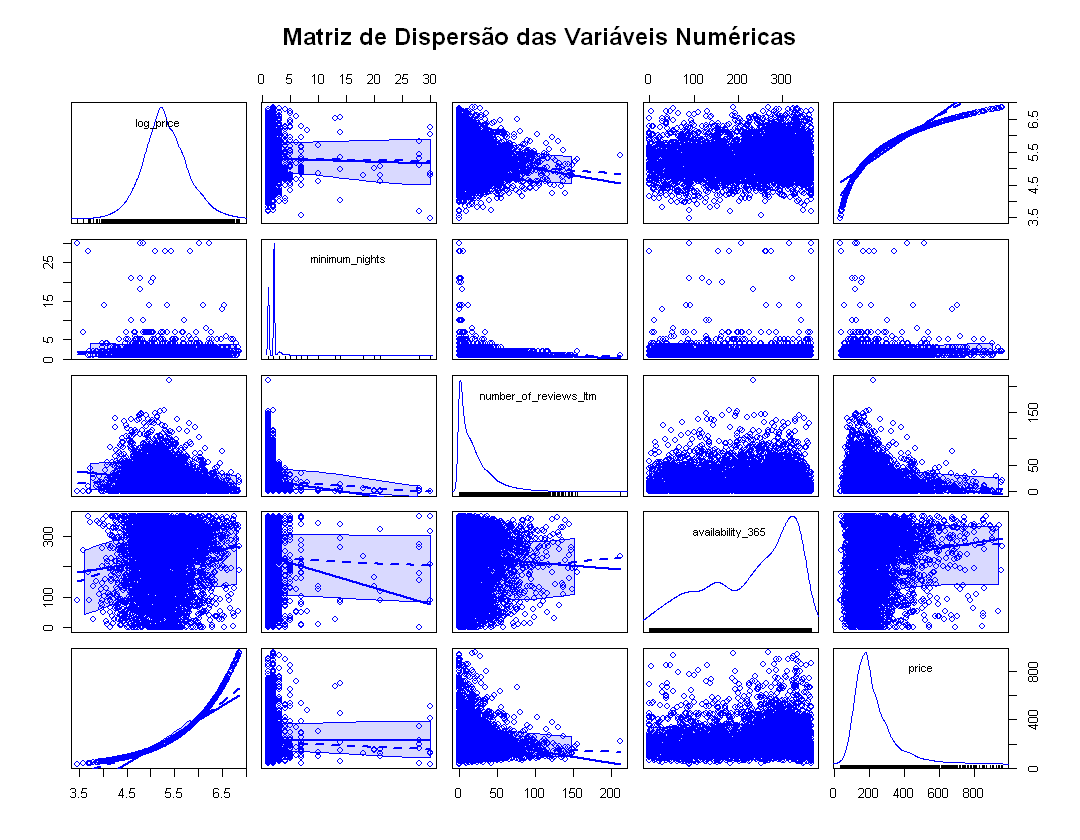

In [ ]:
# Scatter Plot Matrix para variáveis numéricas

par(bg = "white")  # fundo branco
scatterplotMatrix(
  ~ log_price + minimum_nights + number_of_reviews_ltm + availability_365 + price,
  data   = df,
  smooth = FALSE,
  main   = "Matriz de Dispersão das Variáveis Numéricas"
)

#### Distribuição de Preço (Price)

O histograma é _right-skewed_, dado que existem propriedades de luxo - _outliers_ - com preços por noite bastante acima da média 

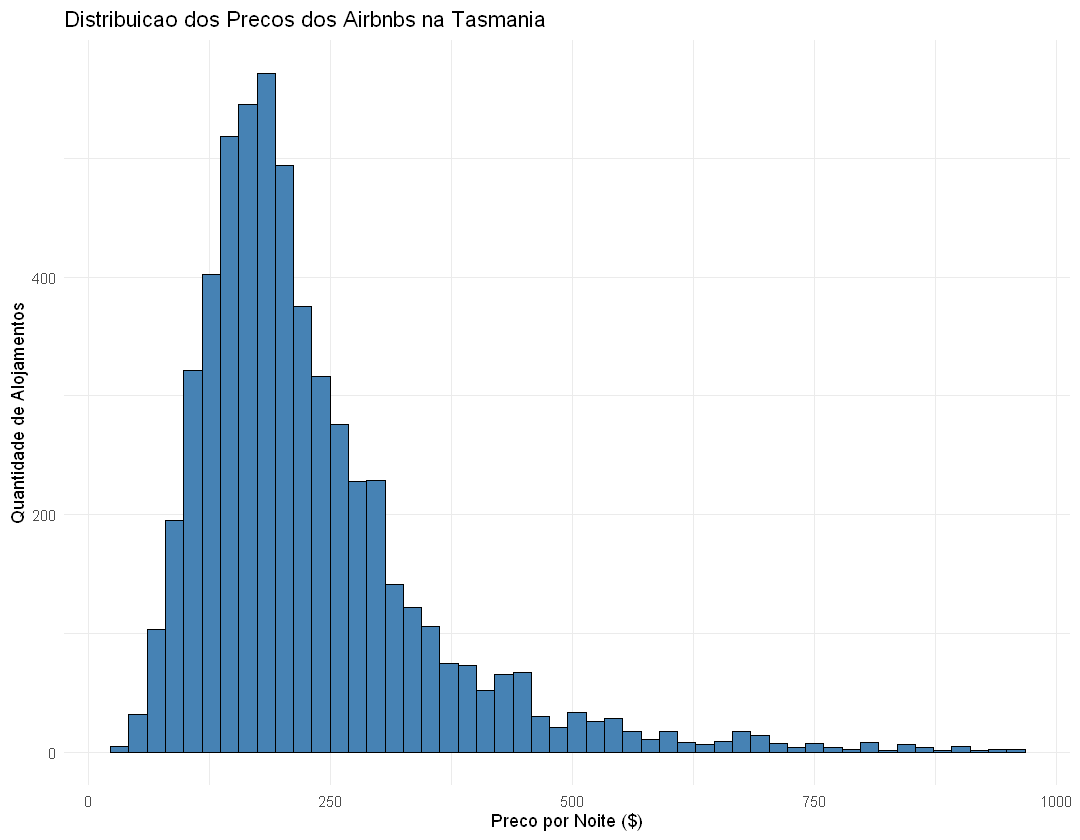

In [18]:
# Distribuicao do preco (variavel alvo)
ggplot(df, aes(x = price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuicao dos Precos dos Airbnbs na Tasmania",
       x = "Preco por Noite ($)",
       y = "Quantidade de Alojamentos")

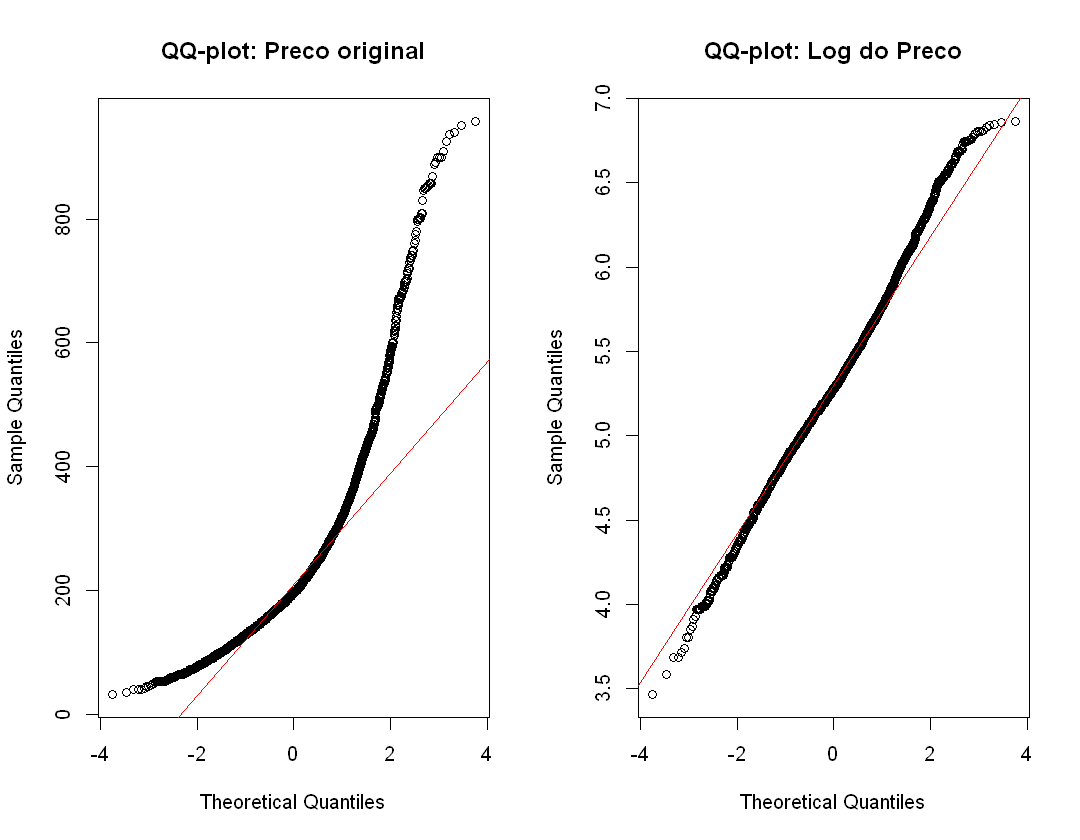

In [19]:
# QQ plot para conferir normalidade do preco original e do log do preco
par(mfrow = c(1, 2))
par(bg = "white")
qqnorm(df$price, main = "QQ-plot: Preco original")
qqline(df$price, col = "red")

qqnorm(df$log_price, main = "QQ-plot: Log do Preco")
qqline(df$log_price, col = "red")
par(mfrow = c(1, 1))

### Preço vs Tipo de Quarto

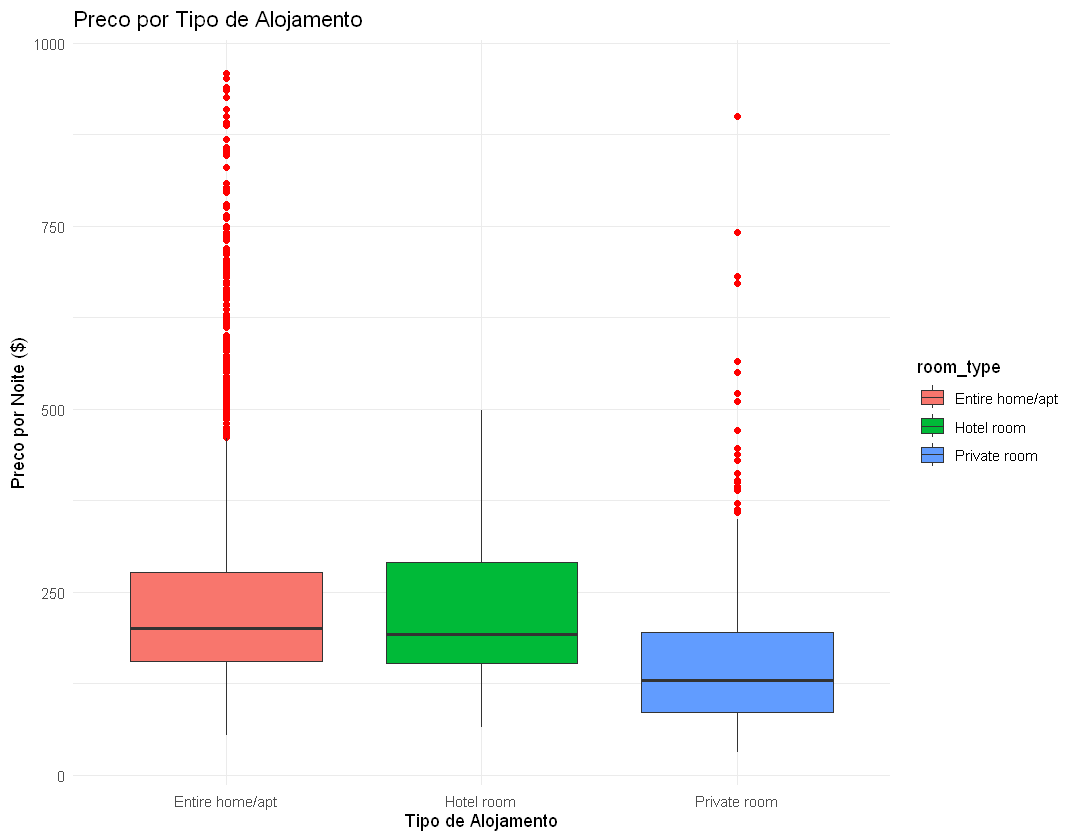

In [20]:
# Distribuicao do preco por tipo de alojamento
ggplot(df, aes(x = room_type, y = price, fill = room_type)) +
  geom_boxplot(outlier.color = "red") +
  theme_minimal() +
  labs(title = "Preco por Tipo de Alojamento",
       x = "Tipo de Alojamento",
       y = "Preco por Noite ($)") 

### Visualização das propriedades em coordenadas

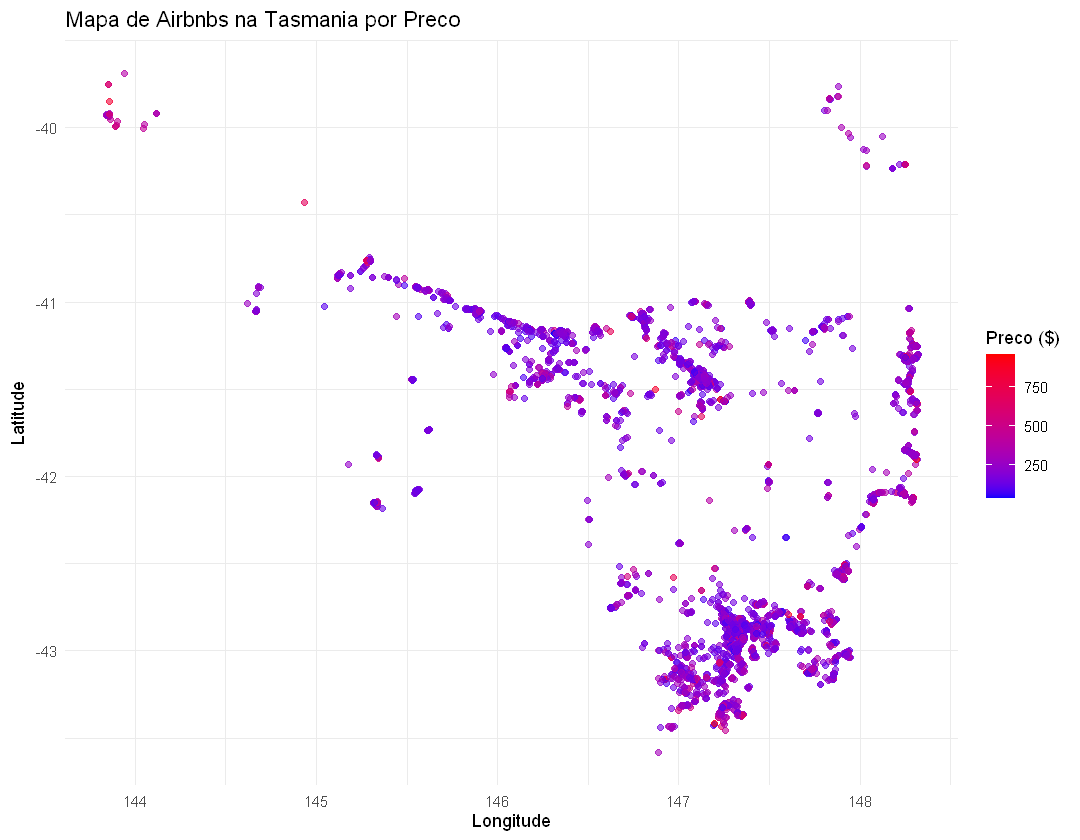

In [21]:
# Mapa de localizacao dos alojamentos colorido pelo preco
ggplot(df, aes(x = longitude, y = latitude, color = price)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_gradient(low = "blue", high = "red") +
  theme_minimal() +
  labs(title = "Mapa de Airbnbs na Tasmania por Preco",
       x = "Longitude",
       y = "Latitude",
       color = "Preco ($)")

### Disponibilidade 365 dias vs Preço

`geom_smooth()` using formula = 'y ~ x'


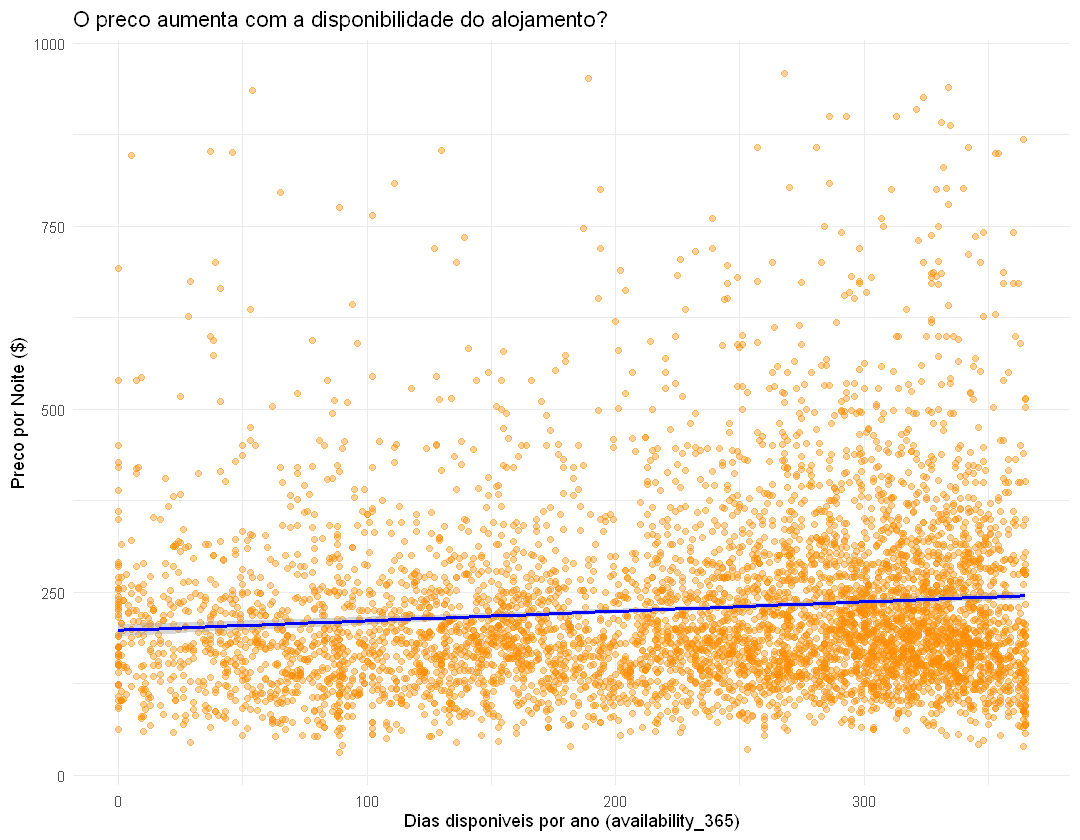

In [22]:
# Relacao entre disponibilidade anual e preco
ggplot(df, aes(x = availability_365, y = price)) +
  geom_point(alpha = 0.4, color = "darkorange") +
  geom_smooth(method = "lm", color = "blue") +
  theme_minimal() +
  labs(title = "O preco aumenta com a disponibilidade do alojamento?",
       x = "Dias disponiveis por ano (availability_365)",
       y = "Preco por Noite ($)")

### Top 10 Bairros com mais Airbnbs

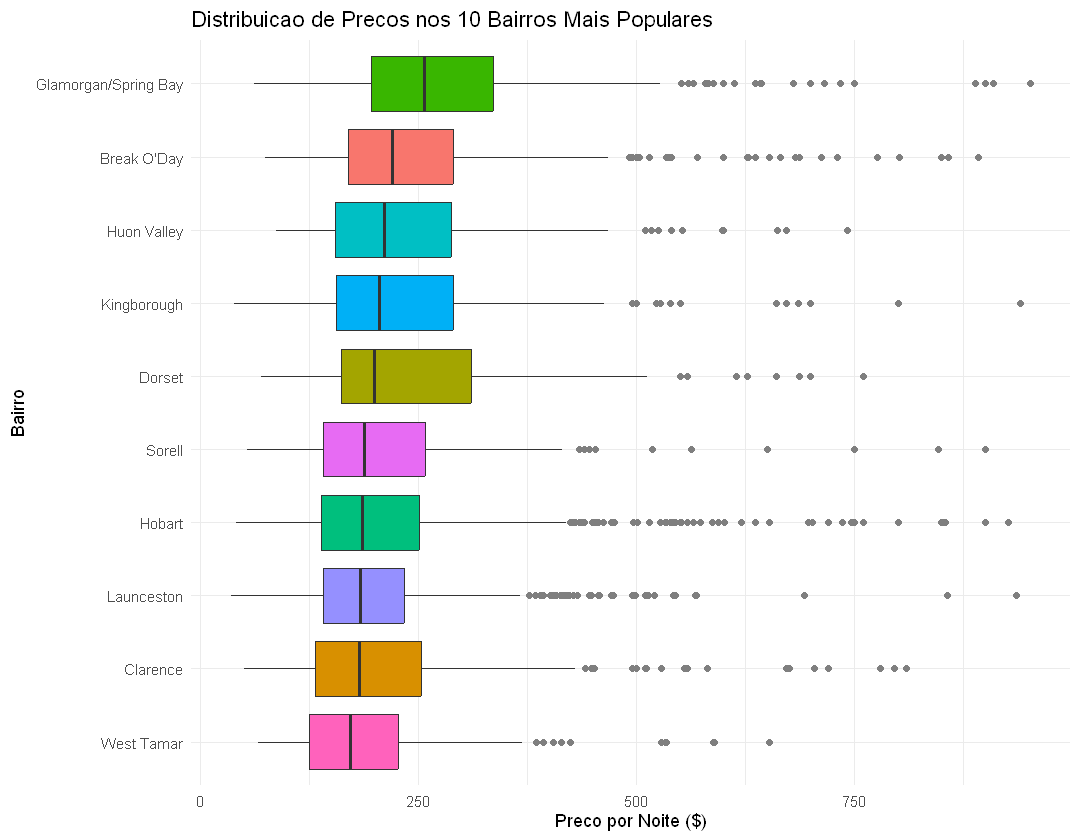

In [23]:
# Distribuicao de precos nos 10 bairros com mais alojamentos
top_10_bairros <- df %>%
  as_tibble() %>%
  dplyr::count(neighbourhood, sort = TRUE) %>%
  head(10) %>%
  dplyr::pull(neighbourhood)

df %>%
  dplyr::filter(neighbourhood %in% top_10_bairros) %>%
  ggplot(aes(x = reorder(neighbourhood, price, FUN = median),
             y = price,
             fill = neighbourhood)) +
  geom_boxplot(outlier.color = "gray50") +
  coord_flip() +
  theme_minimal() +
  labs(title = "Distribuicao de Precos nos 10 Bairros Mais Populares",
       x = "Bairro",
       y = "Preco por Noite ($)") +
  theme(legend.position = "none")

### Distribuição do número mínimo de noites

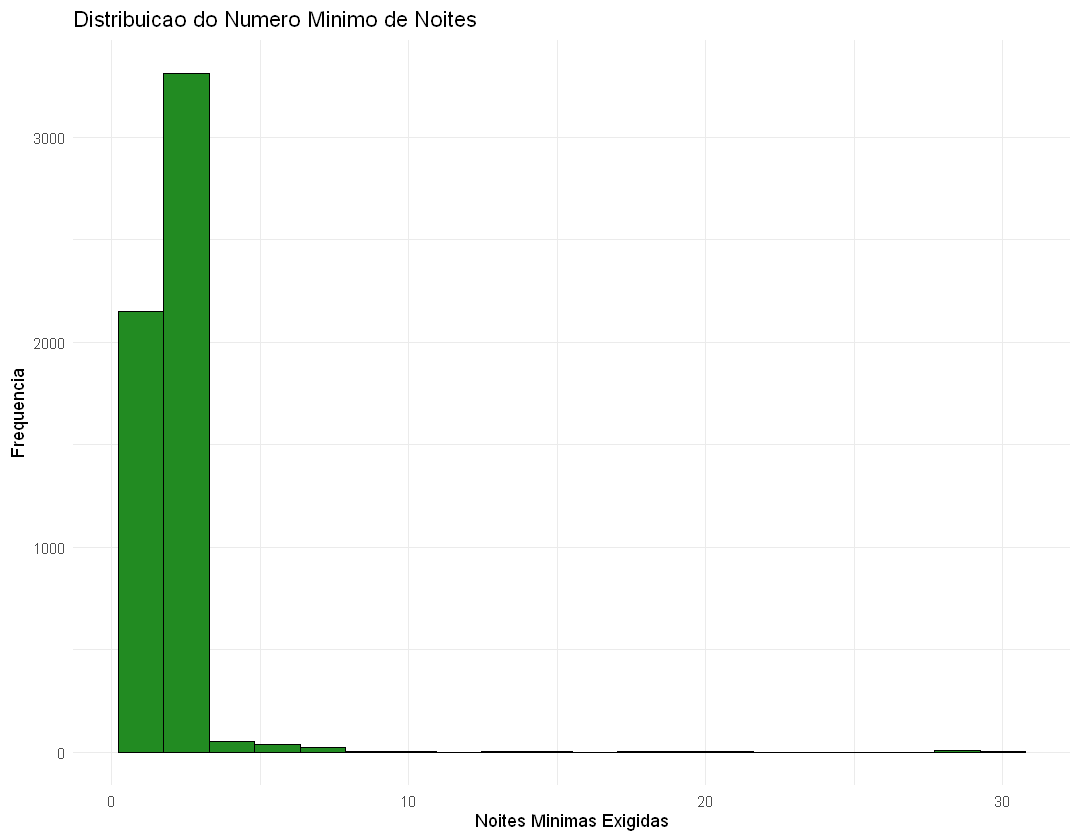

In [24]:
# Distribuicao do numero minimo de noites exigido
ggplot(df, aes(x = minimum_nights)) +
  geom_histogram(fill = "forestgreen", color = "black", bins = 20) +
  theme_minimal() +
  labs(title = "Distribuicao do Numero Minimo de Noites",
       x = "Noites Minimas Exigidas",
       y = "Frequencia")

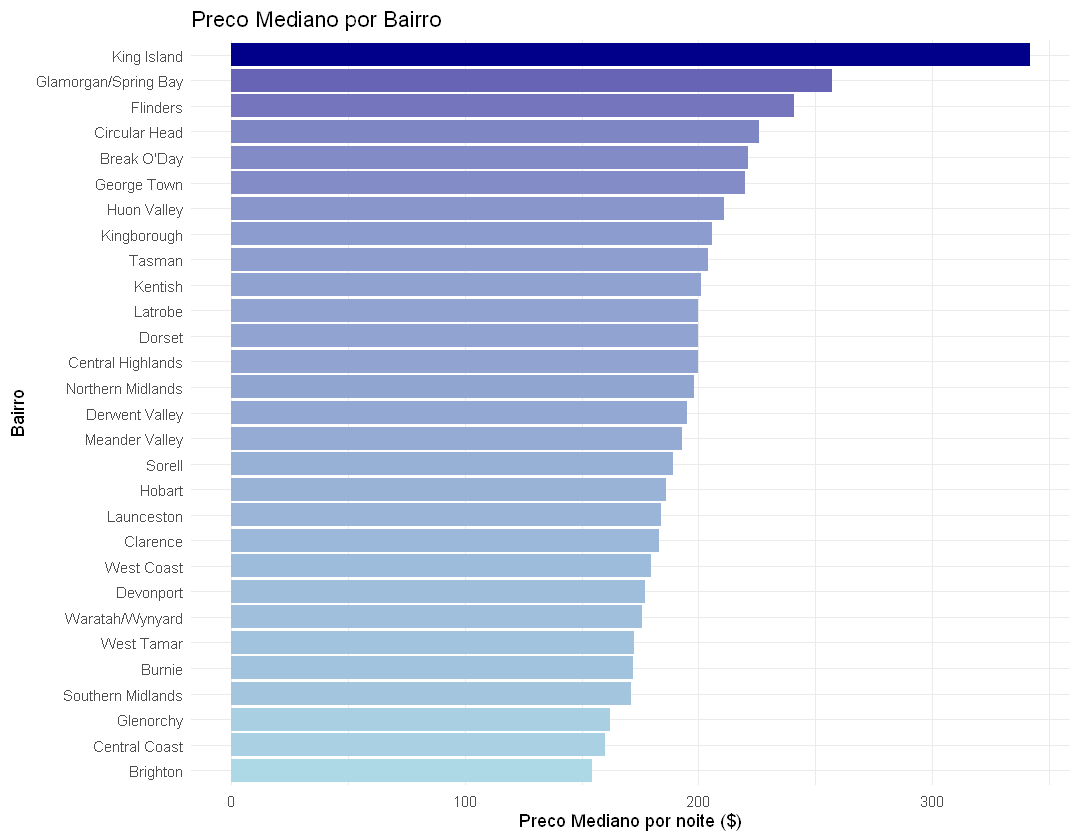

In [25]:
# Preço mediano por bairro
df %>%
  group_by(neighbourhood) %>%
  summarise(preco_mediano = median(price)) %>%
  ggplot(aes(x = reorder(neighbourhood, preco_mediano), y = preco_mediano, fill = preco_mediano)) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  theme_minimal() +
  labs(title = "Preco Mediano por Bairro",
       x = "Bairro",
       y = "Preco Mediano por noite ($)") +
  theme(legend.position = "none")

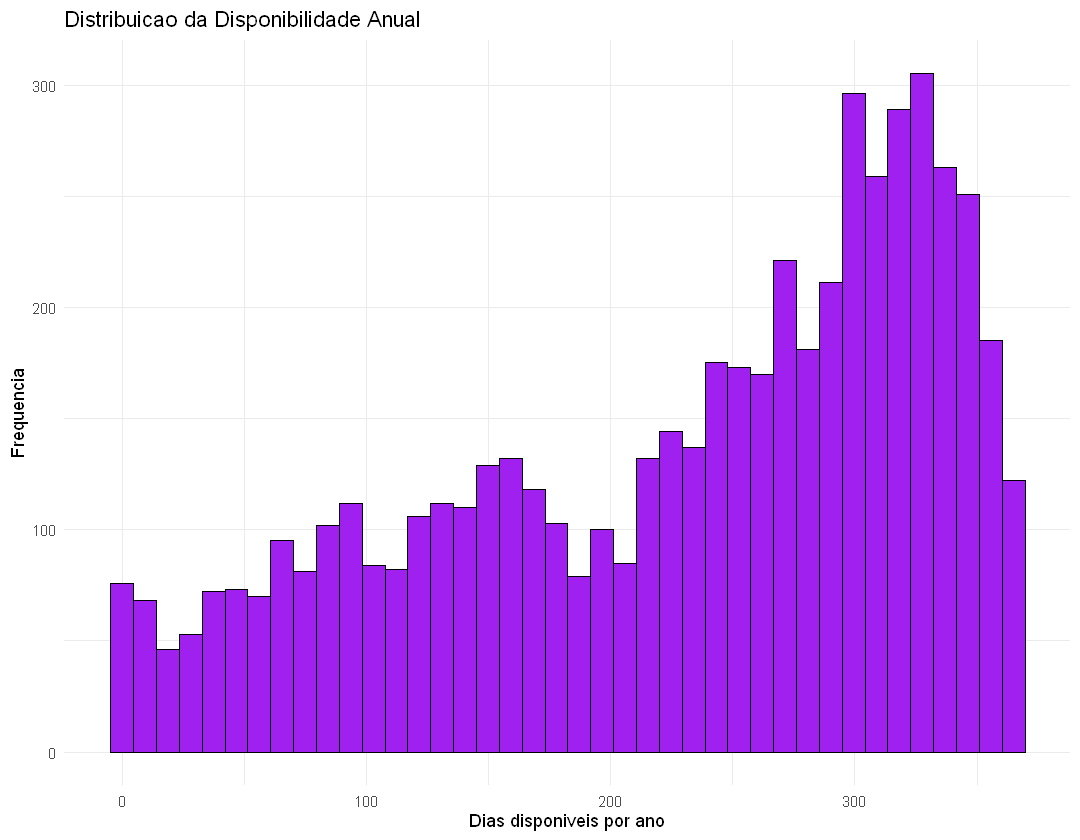

In [26]:
# Distribuicao da disponibilidade anual dos alojamentos
ggplot(df, aes(x = availability_365)) +
  geom_histogram(fill = "purple", color = "black", bins = 40) +
  theme_minimal() +
  labs(title = "Distribuicao da Disponibilidade Anual",
       x = "Dias disponiveis por ano",
       y = "Frequencia")

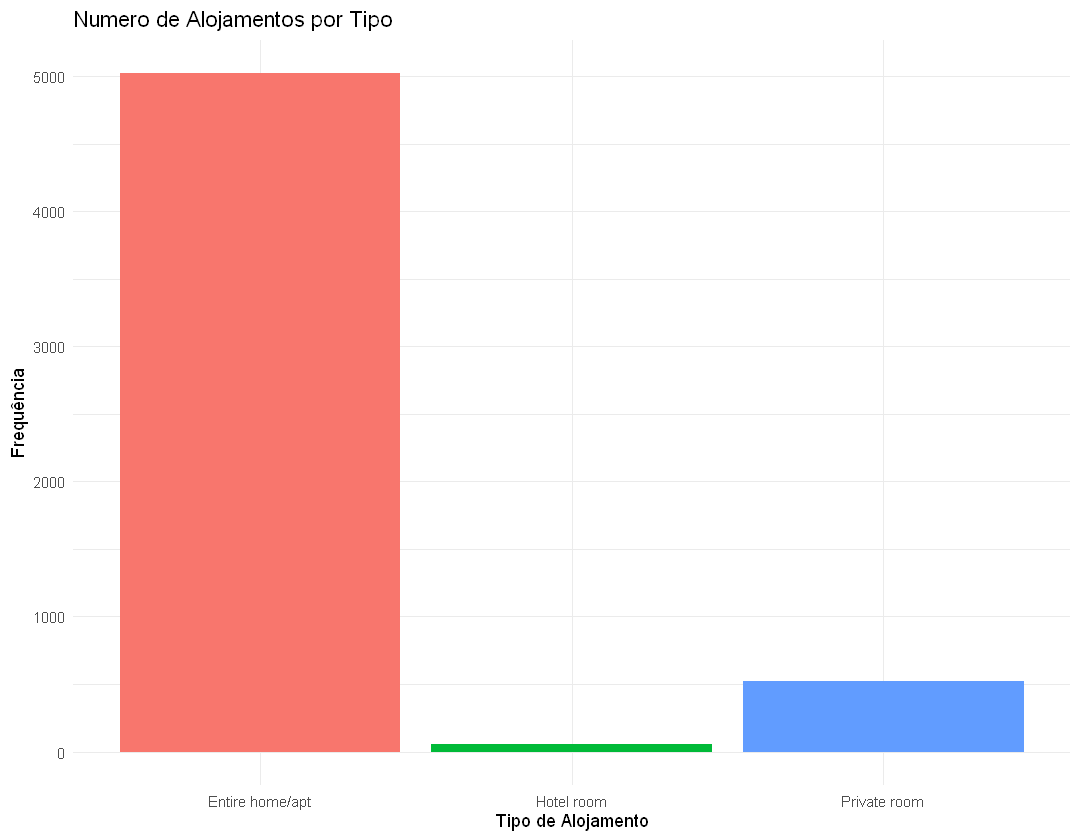

In [27]:
# Contagem de alojamentos por tipo de quarto
ggplot(df, aes(x = room_type, fill = room_type)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Numero de Alojamentos por Tipo",
       x = "Tipo de Alojamento",
       y = "Frequência") +
  theme(legend.position = "none")

### 4. Correlação de Variáveis

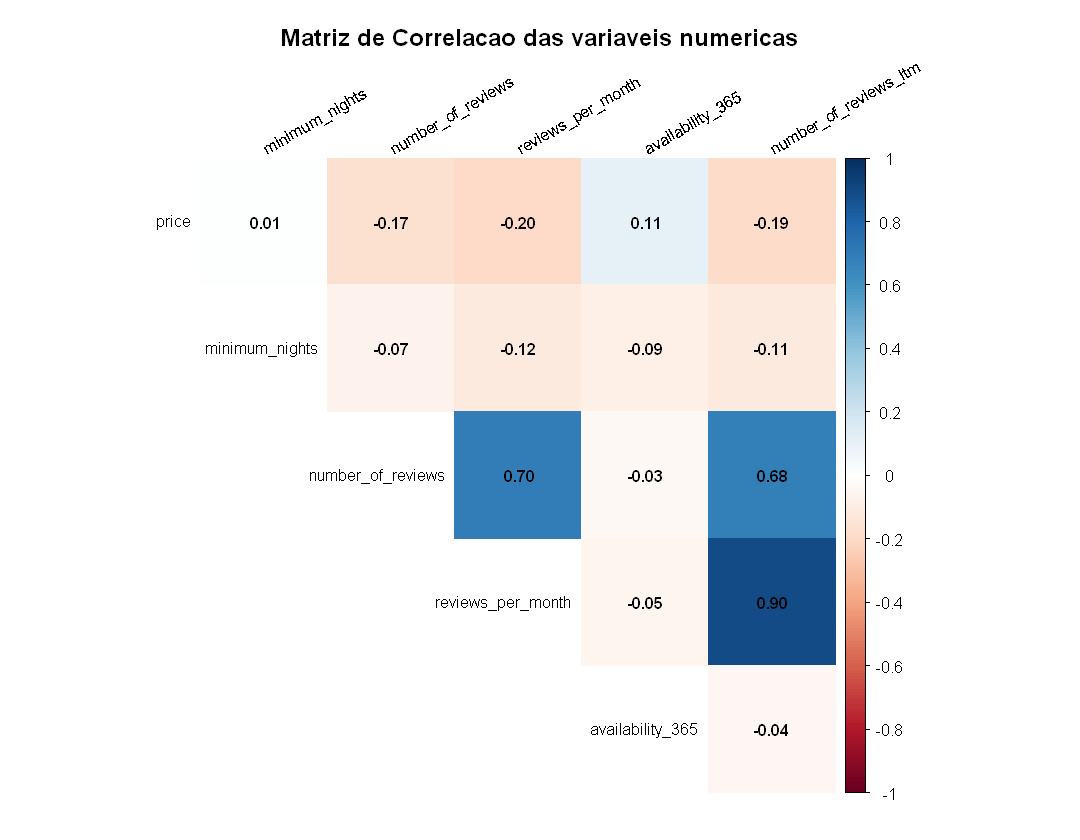

In [60]:
# Matriz de correlacao entre variaveis numericas
# Usamos df_numeric que ja exclui latitude, longitude e calculated_host_listings_count
matriz_cor <- cor(df_numeric, use = "complete.obs")

par(mar = c(1, 1, 3, 1))
par(bg = "white")

corrplot(matriz_cor,
         method = "color",
         type = "upper", # triangulo de cima 
         addCoef.col = "black",
         number.cex = 0.8,
         tl.col = "black",
         tl.srt = 30,
         tl.cex = 0.8,
         diag = FALSE)

title("Matriz de Correlacao das variaveis numericas")

In [ ]:
# Correlação de Spearman, Kendall e Pearson

# Pearson: mede correlação linear entre variáveis quantitativas
# Spearman: mais robusto a outliers e assimetrias
# Kendall: mais adequado para amostras pequenas

cor_spearman <- cor(df_numeric, method = "spearman")
cor_kendall  <- cor(df_numeric, method = "kendall")
cor_pearson  <- cor(df_numeric, method = "pearson")

# Comparar os 3 métodos para a variável alvo : price
tabela_correlacoes <- data.frame(
  variavel = colnames(cor_pearson),
  pearson  = round(cor_pearson[, "price"], 3),
  spearman = round(cor_spearman[, "price"], 3),
  kendall  = round(cor_kendall[, "price"], 3),
  row.names = NULL  # elimina rownames duplicados
)

# tirar a linha de price
tabela_correlacoes <- tabela_correlacoes[tabela_correlacoes$variavel != "price", ]

print(tabela_correlacoes)

               variavel pearson spearman kendall
2        minimum_nights   0.006    0.001   0.001
3     number_of_reviews  -0.169   -0.176  -0.120
4     reviews_per_month  -0.197   -0.207  -0.141
5      availability_365   0.106    0.100   0.067
6 number_of_reviews_ltm  -0.190   -0.200  -0.137


### 5. Feature Engineering

In [30]:
# Remover latitude e longitude - ja nao sao necessarias apos o mapa
# Remover tambem as duas variaveis de reviews redundantes identificadas na correlacao
df <- df %>%
  dplyr::select(-latitude, -longitude, -number_of_reviews, -reviews_per_month)

names(df)

[1] "neighbourhood"         "room_type"             "price"                
[4] "minimum_nights"        "availability_365"      "number_of_reviews_ltm"
[7] "log_price"

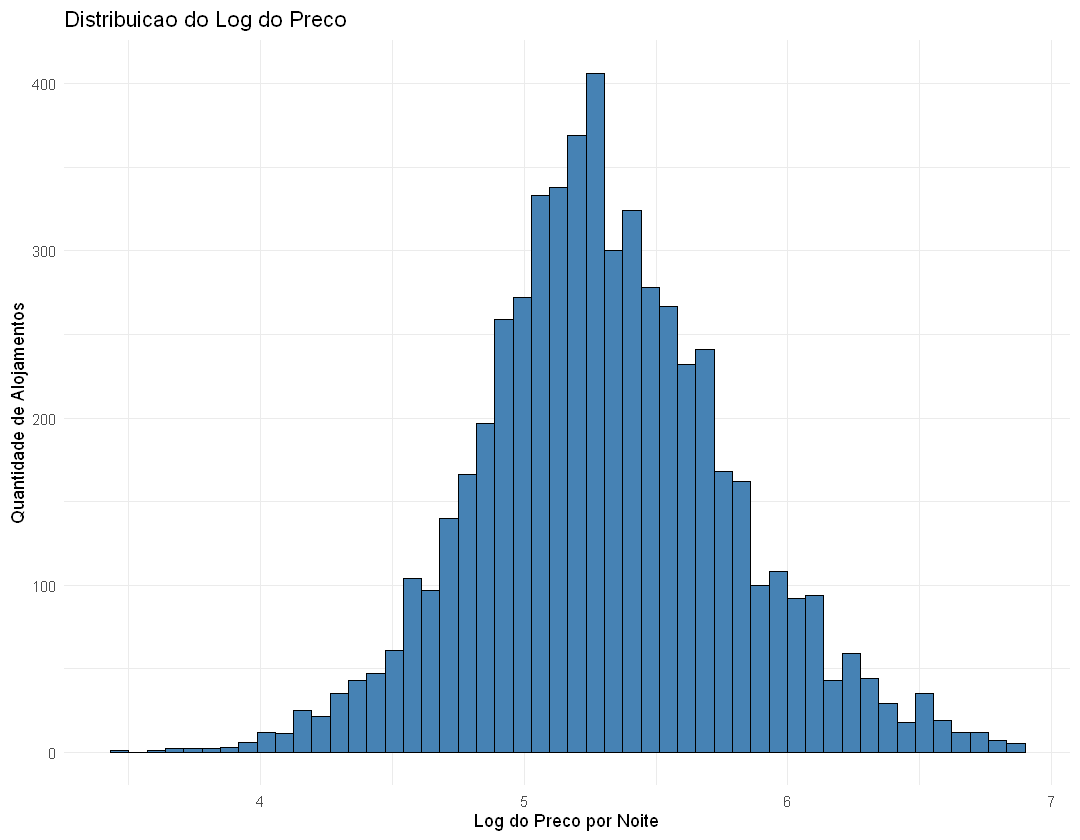

In [31]:
# Confirmacao visual da distribuicao apos transformacao logaritmica
# Deve aproximar-se de uma distribuicao normal
ggplot(df, aes(x = log_price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuicao do Log do Preco",
       x = "Log do Preco por Noite",
       y = "Quantidade de Alojamentos")

In [32]:
# Verificar a distribuicao de alojamentos por bairro
tabela_bairros <- as.data.frame(sort(table(df$neighbourhood), decreasing = TRUE))
colnames(tabela_bairros) <- c("neighbourhood", "n")
tabela_bairros$percentagem <- round(prop.table(tabela_bairros$n) * 100, 2)
tabela_bairros

neighbourhood,n,percentagem
<fct>,<int>,<dbl>
Hobart,1067,19.05
Launceston,587,10.48
Glamorgan/Spring Bay,515,9.19
Kingborough,409,7.30
Clarence,377,6.73
Break O'Day,335,5.98
Huon Valley,216,3.86
West Tamar,184,3.28
Dorset,180,3.21


In [ ]:
# Bairros com menos de 2% dos alojamentos sao agrupados em "Outro"

# Reduz o numero de categorias e evita niveis com muito poucas observacoes
df <- df %>%
  mutate(neighbourhood = fct_lump_prop(neighbourhood,
                                       prop = 0.02,
                                       other_level = "Outro"))

# Confirmar resultado do agrupamento
tabela_bairros_final <- as.data.frame(sort(table(df$neighbourhood), decreasing = TRUE))
colnames(tabela_bairros_final) <- c("neighbourhood", "n")
tabela_bairros_final$percentagem <- round(prop.table(tabela_bairros_final$n) * 100, 2)
tabela_bairros_final

neighbourhood,n,percentagem
<fct>,<int>,<dbl>
Hobart,1067,19.05
Outro,935,16.69
Launceston,587,10.48
Glamorgan/Spring Bay,515,9.19
Kingborough,409,7.30
Clarence,377,6.73
Break O'Day,335,5.98
Huon Valley,216,3.86
West Tamar,184,3.28


### Divisão em treino e teste

In [ ]:
# Divisao estratificada do dataset em treino (80%) e teste (20%)
# A estratificacao por room_type garante que a proporcao de cada tipo de quarto e mantida em ambos os conjuntos, dado o que o dataset tem desequilibrio 

set.seed(131651) # definir seed para reproducibilidade
indices_treino <- sample(1:nrow(df), size = 0.80 * nrow(df)) # amostra aleatoria de indices para treino

df_train <- df[indices_treino, ] # treino com 80% dos dados
df_test  <- df[-indices_treino, ] # teste com os 20% restantes

cat("Numero de observacoes no Treino:", nrow(df_train), "\n")
cat("Numero de observacoes no Teste:", nrow(df_test), "\n")

# Confirmar que as proporcoes foram mantidas
cat("\nDistribuicao no Treino:\n")
print(round(prop.table(table(df_train$room_type)) * 100, 1))

cat("\nDistribuicao no Teste:\n")
print(round(prop.table(table(df_test$room_type)) * 100, 1))

Numero de observacoes no Treino: 4481 
Numero de observacoes no Teste: 1121 

Distribuicao no Treino:

Entire home/apt      Hotel room    Private room 
           89.6             1.0             9.4 

Distribuicao no Teste:

Entire home/apt      Hotel room    Private room 
           89.7             1.1             9.3 


### 6. Usar algoritmos de aprendizagem supervisionada (regressão linear, regressão polinomial, interação de variáveis, regressão não-linear) sobre o seu conjunto de dados

### Modelo 1: Regressão Linear Simples

In [35]:
# Modelo 1: Regressao Linear Simples

# Usado como base, apenas uma variavel preditora
# Esperamos um R^2 baixo, o objetivo e ter um ponto de comparacao
modelo1_simples <- lm(log_price ~ number_of_reviews_ltm, data = df_train)
summary(modelo1_simples)


Call:
lm(formula = log_price ~ number_of_reviews_ltm, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.92120 -0.30599 -0.01403  0.29119  1.56209 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)            5.3911441  0.0095680  563.46   <2e-16 ***
number_of_reviews_ltm -0.0042089  0.0003091  -13.62   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4769 on 4479 degrees of freedom
Multiple R-squared:  0.03974,	Adjusted R-squared:  0.03953 
F-statistic: 185.4 on 1 and 4479 DF,  p-value: < 2.2e-16


### Modelo 2: Regressao Linear Multipla

In [36]:
# Modelo 2: Regressao Linear Multipla
# Inclui todas as variaveis relevantes apos feature engineering

modelo2_multipla <- lm(log_price ~ neighbourhood + room_type +
                                   minimum_nights + number_of_reviews_ltm +
                                   availability_365,
                       data = df_train)
summary(modelo2_multipla)


Call:
lm(formula = log_price ~ neighbourhood + room_type + minimum_nights + 
    number_of_reviews_ltm + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.46256 -0.29988 -0.02758  0.25076  1.90372 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.502e+00  3.312e-02 166.119  < 2e-16 ***
neighbourhoodCentral Coast        -2.295e-01  4.923e-02  -4.662 3.23e-06 ***
neighbourhoodCircular Head         4.854e-02  5.055e-02   0.960 0.336908    
neighbourhoodClarence             -1.740e-01  3.657e-02  -4.758 2.02e-06 ***
neighbourhoodDorset               -1.041e-01  4.583e-02  -2.272 0.023151 *  
neighbourhoodGlamorgan/Spring Bay  9.362e-02  3.437e-02   2.724 0.006478 ** 
neighbourhoodGlenorchy            -3.208e-01  5.391e-02  -5.950 2.89e-09 ***
neighbourhoodHobart               -1.547e-01  3.074e-02  -5.032 5.04e-07 ***
neighbourhoodHuon Valley          -6.543e-02  4

### Modelo 3: Regressão Polinomial

In [37]:
# Adiciona o termo quadrático I(number_of_reviews_ltm^2) para testar se a relação entre
# number_of_reviews_ltm e o preço tem uma componente não-linear

modelo3_poli <- lm(log_price ~ neighbourhood + room_type +
                               number_of_reviews_ltm +
                               I(number_of_reviews_ltm^2) +
                               minimum_nights +
                               availability_365,
                   data = df_train)
summary(modelo3_poli)


Call:
lm(formula = log_price ~ neighbourhood + room_type + number_of_reviews_ltm + 
    I(number_of_reviews_ltm^2) + minimum_nights + availability_365, 
    data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.49713 -0.29740 -0.02826  0.25688  1.88245 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.546e+00  3.357e-02 165.180  < 2e-16 ***
neighbourhoodCentral Coast        -2.313e-01  4.898e-02  -4.722 2.41e-06 ***
neighbourhoodCircular Head         4.910e-02  5.029e-02   0.976 0.328896    
neighbourhoodClarence             -1.693e-01  3.639e-02  -4.653 3.37e-06 ***
neighbourhoodDorset               -1.033e-01  4.560e-02  -2.266 0.023498 *  
neighbourhoodGlamorgan/Spring Bay  8.820e-02  3.421e-02   2.579 0.009955 ** 
neighbourhoodGlenorchy            -3.166e-01  5.364e-02  -5.903 3.83e-09 ***
neighbourhoodHobart               -1.471e-01  3.061e-02  -4.805 1.60e-06 ***
neighbourhood

### Modelo 4: Regressão Não-Linear

In [38]:
# Regressão não-linear: transformação log no preditor

modelo4_naolinear <- lm(log_price ~ neighbourhood + room_type +
                                   log(minimum_nights + 1) + # podem ter valor 0, entao somamos 1 para evitar log(0)
                                   log(number_of_reviews_ltm + 1) +
                                   availability_365, # nao foi transformada em log porque tem uma distribuição mais próxima da normal, não tendo uma assimetria acentuada
                       data = df_train)
summary(modelo4_naolinear)


Call:
lm(formula = log_price ~ neighbourhood + room_type + log(minimum_nights + 
    1) + log(number_of_reviews_ltm + 1) + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.54860 -0.29362 -0.02518  0.25208  1.84361 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.736e+00  4.373e-02 131.168  < 2e-16 ***
neighbourhoodCentral Coast        -2.484e-01  4.871e-02  -5.100 3.54e-07 ***
neighbourhoodCircular Head         2.579e-02  5.008e-02   0.515 0.606592    
neighbourhoodClarence             -1.805e-01  3.617e-02  -4.990 6.26e-07 ***
neighbourhoodDorset               -1.089e-01  4.534e-02  -2.401 0.016370 *  
neighbourhoodGlamorgan/Spring Bay  7.442e-02  3.402e-02   2.187 0.028775 *  
neighbourhoodGlenorchy            -3.311e-01  5.333e-02  -6.209 5.82e-10 ***
neighbourhoodHobart               -1.546e-01  3.044e-02  -5.079 3.95e-07 ***
neighbourhoodHuon Valley     

### Modelo 5: Regressão Linear com Interação

In [39]:
# (neighbourhood * room_type cria a interação entre o bairro e o tipo de quarto)
# Este modelo testa se o efeito do tipo de quarto no preço varia dependendo do bairro, ou seja, se há uma interação entre essas duas variáveis.
# O problema adicionado é que este modelo adiciona muitos parâmetros (um para cada combinação de bairro e tipo de quarto) e diminui a interepretabilidade do modelo,
# mas pode melhorar o ajuste se realmente houver uma interação significativa entre essas variáveis.

modelo5_interacao <- lm(log_price ~ neighbourhood * room_type +
                                    minimum_nights +
                                    number_of_reviews_ltm +
                                    availability_365,
                        data = df_train)

summary(modelo5_interacao)


Call:
lm(formula = log_price ~ neighbourhood * room_type + minimum_nights + 
    number_of_reviews_ltm + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.52538 -0.29300 -0.02427  0.24818  1.86391 

Coefficients: (7 not defined because of singularities)
                                                          Estimate Std. Error
(Intercept)                                              5.499e+00  3.392e-02
neighbourhoodCentral Coast                              -2.452e-01  5.526e-02
neighbourhoodCircular Head                              -4.230e-02  5.658e-02
neighbourhoodClarence                                   -1.361e-01  3.837e-02
neighbourhoodDorset                                     -9.219e-02  4.738e-02
neighbourhoodGlamorgan/Spring Bay                        9.745e-02  3.532e-02
neighbourhoodGlenorchy                                  -2.833e-01  5.658e-02
neighbourhoodHobart                                     -1.429e-01  3.207e-

In [40]:
# Modelo 6: Regressão Linear com Coordenadas Geográficas
# Latitude e longitude capturam variação geográfica dentro de cada bairro
# Dois alojamentos no mesmo bairro podem ter preços diferentes
# dependendo da sua localização exata (proximidade à costa, centro, etc.)

df_train_geo <- df_train
df_train_geo$latitude  <- dados[rownames(df_train), "latitude"] # latitude e longitude sao recuperados do dataset original (dados) usando os indices das linhas de df_train
df_train_geo$longitude <- dados[rownames(df_train), "longitude"]

df_test_geo <- df_test
df_test_geo$latitude  <- dados[rownames(df_test), "latitude"]
df_test_geo$longitude <- dados[rownames(df_test), "longitude"]

modelo6_geo <- lm(log_price ~ neighbourhood + room_type +
                              latitude + longitude +
                              minimum_nights +
                              number_of_reviews_ltm +
                              availability_365,
                  data = df_train_geo)

summary(modelo6_geo)


Call:
lm(formula = log_price ~ neighbourhood + room_type + latitude + 
    longitude + minimum_nights + number_of_reviews_ltm + availability_365, 
    data = df_train_geo)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.45885 -0.30117 -0.02706  0.25209  1.90909 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        6.842e+00  1.299e+00   5.269 1.44e-07 ***
neighbourhoodCentral Coast        -2.291e-01  4.924e-02  -4.653 3.37e-06 ***
neighbourhoodCircular Head         4.821e-02  5.055e-02   0.954 0.340315    
neighbourhoodClarence             -1.732e-01  3.658e-02  -4.736 2.25e-06 ***
neighbourhoodDorset               -1.042e-01  4.584e-02  -2.272 0.023112 *  
neighbourhoodGlamorgan/Spring Bay  9.337e-02  3.437e-02   2.716 0.006626 ** 
neighbourhoodGlenorchy            -3.201e-01  5.394e-02  -5.934 3.19e-09 ***
neighbourhoodHobart               -1.544e-01  3.076e-02  -5.019 5.40e-07 ***
neighbourhoodHu

## Pressupostos do Modelo de Regressão Linear

Antes de validar qualquer modelo de regressão linear, é necessário verificar
os seguintes pressupostos sobre os resíduos (ε):

1. **Valor esperado nulo**: E(ε) = 0: os erros têm média zero
2. **Homocedasticidade**: Var(ε) = σ² constante: variância dos erros é constante
3. **Independência**: Cov(εi, εj) = 0 : os erros são linearmente independentes
4. **Normalidade**: ε ~ N(0, σ²) : os erros seguem distribuição normal
5. **Exogeneidade**: Cov(εi, xi) = 0 : não existe relação entre erros e variáveis independentes

In [41]:
# R^2 Ajustado e Teste F Global para todos os modelos
# R^2 ajustado penaliza variáveis que não contribuem para o modelo

# Teste F global: H0: todos os βi = 0 (modelo não é útil)
# Se p-value < 0.05, rejeitamos H0

modelos <- list(
  "1 Linear Simples"   = modelo1_simples,
  "2 Linear Múltipla"  = modelo2_multipla,
  "3 Polinomial"       = modelo3_poli,
  "4 Não-Linear (log)" = modelo4_naolinear,
  "5 Interação"        = modelo5_interacao
)

for (nome in names(modelos)) {
  s <- summary(modelos[[nome]])
  f <- s$fstatistic # estatística F global
  p_value <- pf(f[1], f[2], f[3], lower.tail = FALSE)  # p-value do teste F global
  
  cat("──────────────────────────────────────\n")
  cat("Modelo:", nome, "\n")
  cat("R^2 Ajustado:    ", round(s$adj.r.squared, 4), "\n")
  cat("Estatística F:  ", round(f[1], 2), "\n")
  cat("p-value Teste F:", format(p_value, scientific = TRUE, digits = 3), "\n") # formatação do p-value
}

──────────────────────────────────────
Modelo: 1 Linear Simples 
R^2 Ajustado:     0.0395 
Estatística F:   185.36 
p-value Teste F: 2.16e-41 
──────────────────────────────────────
Modelo: 2 Linear Múltipla 
R^2 Ajustado:     0.1876 
Estatística F:   52.73 
p-value Teste F: 3.79e-188 
──────────────────────────────────────
Modelo: 3 Polinomial 
R^2 Ajustado:     0.1959 
Estatística F:   52.96 
p-value Teste F: 3.21e-197 
──────────────────────────────────────
Modelo: 4 Não-Linear (log) 
R^2 Ajustado:     0.2053 
Estatística F:   58.86 
p-value Teste F: 4.06e-209 
──────────────────────────────────────
Modelo: 5 Interação 
R^2 Ajustado:     0.2015 
Estatística F:   27.29 
p-value Teste F: 3.77e-191 


In [61]:
# Verificação de Multicolinearidade com VIF 

# Regra: eliminar variáveis com VIF > 5
# Se VIF = 1 nao ha correlação com outras variáveis
# Se VIF > 5 há multicolinearidade 

for (nome in names(modelos)) {
  cat("──────────────────────────────────────\n")
  cat("VIF: ", nome, "\n")
  tryCatch(
    print(vif(modelos[[nome]])),
    error = function(e) cat("VIF não aplicável:", e$message, "\n")
  )
  cat("\n")
}

──────────────────────────────────────
VIF:  1 Linear Simples 
VIF não aplicável: model contains fewer than 2 terms 

──────────────────────────────────────
VIF:  2 Linear Múltipla 
                          GVIF Df GVIF^(1/(2*Df))
neighbourhood         1.108748 15        1.003447
room_type             1.096947  2        1.023402
minimum_nights        1.040141  1        1.019873
number_of_reviews_ltm 1.049766  1        1.024581
availability_365      1.038760  1        1.019196

──────────────────────────────────────
VIF:  3 Polinomial 
                               GVIF Df GVIF^(1/(2*Df))
neighbourhood              1.121262 15        1.003822
room_type                  1.119232  2        1.028561
number_of_reviews_ltm      5.253699  1        2.292095
I(number_of_reviews_ltm^2) 5.125565  1        2.263971
minimum_nights             1.042095  1        1.020831
availability_365           1.038773  1        1.019202

──────────────────────────────────────
VIF:  4 Não-Linear (log) 
       

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



VIF não aplicável: there are aliased coefficients in the model 



### VIF Multicolinearidade

**Modelo 1**: só tem um preditor, não existe multicolinearidade.

**Modelo 2**: Todos os GVIF estão próximos de 1 e muito abaixo de 5.
Sem multicolinearidade. as variáveis selecionadas são independentes entre si.

**Modelo 3**: Os termos number_of_reviews_ltm e I(number_of_reviews_ltm^2) 
apresentam GVIF de 5.25 e 5.13, acima do limiar de 5.
Isto é esperado num modelo polinomial: a variável e o seu quadrado
são naturalmente correlacionados. Não é uma razão para eliminar o modelo.

**Modelo 4**: Todos os valores abaixo de 5.

**Modelo 5**: VIF não calculável

In [62]:
# Verificação formal dos pressupostos de todos os modelos

# Pressuposto 1: média nula H0: E(ε) = 0
# Pressuposto 2: homocedasticidade: Breusch-Pagan H0: variância constante
# Pressuposto 3: independência: Breusch-Godfrey H0: resíduos independentes
# Pressuposto 4: normalidade: Jarque-Bera H0: resíduos normalmente distribuídos

# se p-value > 0.05, não rejeitamos H0, pressuposto verificado

for (nome in names(modelos)) {
  modelo <- modelos[[nome]]
  cat("══════════════════════════════════════════\n")
  cat("Modelo:", nome, "\n")

  # Pressuposto 1 média nula
  cat("P1: Média dos resíduos: ",
      format(mean(modelo$residuals), scientific = TRUE, digits = 3), "\n\n")

  # Pressuposto 2 Breusch-Pagan
  bp <- tryCatch(bptest(modelo), error = function(e) NULL)
  if (!is.null(bp)) {
    cat("P2: Breusch-Pagan (homocedasticidade):\n")
    cat("p-value =", round(bp$p.value, 4),
        "|", ifelse(bp$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")
  }

  # Pressuposto 3 Breusch-Godfrey
  bg <- tryCatch(bgtest(modelo), error = function(e) NULL)
  if (!is.null(bg)) {
    cat("P3: Breusch-Godfrey (independência):\n")
    cat("p-value =", round(bg$p.value, 4),
        "|", ifelse(bg$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")
  }

  # Pressuposto 4 Jarque-Bera
  jb <- tryCatch(jarque.bera.test(modelo$residuals), error = function(e) NULL)
  if (!is.null(jb)) {
    cat("P4: Jarque-Bera (normalidade):\n")
    cat("p-value =", round(jb$p.value, 4),
        "|", ifelse(jb$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")
  }
}

══════════════════════════════════════════
Modelo: 1 Linear Simples 
P1: Média dos resíduos:  -6.11e-18 

P2: Breusch-Pagan (homocedasticidade):
p-value = 0 | ✗ Violado 

P3: Breusch-Godfrey (independência):
p-value = 0.725 | ✓ Verificado 

P4: Jarque-Bera (normalidade):
p-value = 0 | ✗ Violado 

══════════════════════════════════════════
Modelo: 2 Linear Múltipla 
P1: Média dos resíduos:  2.1e-18 

P2: Breusch-Pagan (homocedasticidade):
p-value = 0 | ✗ Violado 

P3: Breusch-Godfrey (independência):
p-value = 0.6096 | ✓ Verificado 

P4: Jarque-Bera (normalidade):
p-value = 0 | ✗ Violado 

══════════════════════════════════════════
Modelo: 3 Polinomial 
P1: Média dos resíduos:  -1.05e-17 

P2: Breusch-Pagan (homocedasticidade):
p-value = 0 | ✗ Violado 

P3: Breusch-Godfrey (independência):
p-value = 0.8019 | ✓ Verificado 

P4: Jarque-Bera (normalidade):
p-value = 0 | ✗ Violado 

══════════════════════════════════════════
Modelo: 4 Não-Linear (log) 
P1: Média dos resíduos:  1.01e-17 

P2

In [ ]:
# Critérios de Informação: AIC e BIC
# AIC e BIC penalizam modelos com mais parâmetros. Quanto menor, melhor
# BIC penaliza mais fortemente modelos com muitos parâmetros

tabela_aic_bic <- data.frame(
  modelo = c("Linear Simples", "Linear Múltipla",
             "Polinomial", "Não-Linear (log)", "Interação"),
  AIC = round(c(AIC(modelo1_simples), AIC(modelo2_multipla),
                AIC(modelo3_poli),    AIC(modelo4_naolinear),
                AIC(modelo5_interacao)), 2),
  BIC = round(c(BIC(modelo1_simples), BIC(modelo2_multipla),
                BIC(modelo3_poli),    BIC(modelo4_naolinear),
                BIC(modelo5_interacao)), 2)
)

print(tabela_aic_bic)

            modelo     AIC     BIC
1   Linear Simples 6085.52 6104.74
2  Linear Múltipla 5354.20 5495.17
3       Polinomial 5309.38 5456.76
4 Não-Linear (log) 5255.59 5396.55
5        Interação 5299.67 5588.01


In [45]:
# Função de avaliação dos modelos no conjunto de teste

# RMSE: raiz do erro quadrático médio, penaliza erros grandes
# MAE: erro absoluto médio, mais robusto a outliers
# MAPE: erro percentual médio absoluto
# R^2: proporção da variância explicada pelo modelo

avaliar_modelo <- function(modelo, dados_teste, nome_modelo) {

  # Previsões no conjunto de teste
  previsoes_log <- predict(modelo, newdata = dados_teste)

  # Converter de volta à escala original
  previsoes_orig <- exp(previsoes_log)
  reais_orig     <- exp(dados_teste$log_price)

  # Métricas na escala logarítmica
  residuos_log <- dados_teste$log_price - previsoes_log
  rmse_log <- sqrt(mean(residuos_log^2))
  mae_log  <- mean(abs(residuos_log))

  # R^2 no teste
  ss_res   <- sum(residuos_log^2)
  ss_tot   <- sum((dados_teste$log_price - mean(dados_teste$log_price))^2)
  r2_teste <- 1 - (ss_res / ss_tot)

  # Métricas na escala original
  rmse_orig <- sqrt(mean((reais_orig - previsoes_orig)^2))
  mae_orig  <- mean(abs(reais_orig - previsoes_orig))

  # MAPE — erro percentual médio absoluto
  # Uma das melhores métricas pois é dada em percentagem (não depende da escala)
  mape <- mean(abs((reais_orig - previsoes_orig) / reais_orig)) * 100

  cat("──────────────────────────────────────\n")
  cat("Modelo:", nome_modelo, "\n")
  cat("R^2 Teste:        ", round(r2_teste, 4), "\n")
  cat("RMSE (log):      ", round(rmse_log, 4), "\n")
  cat("MAE  (log):      ", round(mae_log, 4), "\n")
  cat("RMSE ($ orig):   ", round(rmse_orig, 2), "\n")
  cat("MAE  ($ orig):   ", round(mae_orig, 2), "\n")
  cat("MAPE (%):        ", round(mape, 2), "\n")

  return(data.frame(
    modelo    = nome_modelo,
    r2_teste  = round(r2_teste, 4),
    rmse_log  = round(rmse_log, 4),
    mae_log   = round(mae_log, 4),
    rmse_orig = round(rmse_orig, 2),
    mae_orig  = round(mae_orig, 2),
    mape      = round(mape, 2)
  ))
}

# Re-avaliar todos os modelos com a função atualizada
resultado1 <- avaliar_modelo(modelo1_simples,    df_test, "1 - Linear Simples")
resultado2 <- avaliar_modelo(modelo2_multipla,   df_test, "2 - Linear Multipla")
resultado3 <- avaliar_modelo(modelo3_poli,       df_test, "3 - Polinomial")
resultado4 <- avaliar_modelo(modelo4_naolinear,  df_test, "4 - Nao-Linear (log)")
resultado5 <- avaliar_modelo(modelo5_interacao,  df_test, "5 - Interacao")
resultado6 <- avaliar_modelo(modelo6_geo, df_test_geo, "6 - Geo (lat/lon)")

──────────────────────────────────────
Modelo: 1 - Linear Simples 
R^2 Teste:         0.0195 
RMSE (log):       0.4622 
MAE  (log):       0.3584 
RMSE ($ orig):    121.55 
MAE  ($ orig):    81.34 
MAPE (%):         37.43 
──────────────────────────────────────
Modelo: 2 - Linear Multipla 
R^2 Teste:         0.1354 
RMSE (log):       0.434 
MAE  (log):       0.3397 
RMSE ($ orig):    116.2 
MAE  ($ orig):    77.75 
MAPE (%):         34.65 
──────────────────────────────────────
Modelo: 3 - Polinomial 
R^2 Teste:         0.1374 
RMSE (log):       0.4335 
MAE  (log):       0.3404 
RMSE ($ orig):    116.15 
MAE  ($ orig):    78.02 
MAPE (%):         34.67 
──────────────────────────────────────
Modelo: 4 - Nao-Linear (log) 
R^2 Teste:         0.1344 
RMSE (log):       0.4343 
MAE  (log):       0.3399 
RMSE ($ orig):    116.52 
MAE  ($ orig):    78.31 
MAPE (%):         34.74 
──────────────────────────────────────
Modelo: 5 - Interacao 
R^2 Teste:         0.1483 
RMSE (log):       0.4308 


### Seleção do Modelo Final

Com base na análise comparativa, identificámos dois modelos candidatos:

- **Modelo 4 (Não-Linear)**: melhor AIC/BIC e R^2 ajustado
- **Modelo 5 (Interação)**: melhor R^2 e RMSE no conjunto de teste

Após análise comparativa de todos os modelos, o **Modelo 4 Regressão
Não-Linear (log nos preditores)** foi selecionado como modelo final.

**Justificação:**
- Melhor AIC (5255) e BIC (5396) de todos os modelos
- Maior R^2 ajustado no treino (0.2053): melhor ajuste penalizando parâmetros
- Apenas 21 coeficientes: igual ao Modelo 2
- Os coeficientes têm interpretação direta:
  um aumento de 1% nas reviews recentes implica uma redução de 0.109% no preço
- O Teste de Chow confirmou que não existe estrutura diferencial
  que justifique modelos mais complexos

O Modelo 5 (Interação) apresenta RMSE ligeiramente inferior ($115.47 vs $116.52)
mas esta diferença de $1.05 não justifica 48 coeficientes face aos 21 do Modelo 4 e uma interpretabilidade mais complexa.

In [46]:
melhor_modelo <- modelo4_naolinear

In [ ]:
# Teste de Goldfeld-Quandt à Homocedasticidade
# Complementa o Breusch-Pagan

# H0: erros homocedásticos
# Se p-value > 0.05 → não rejeitamos H0 → pressuposto verificado
cat("Goldfeld-Quandt:\n")
gq <- gqtest(melhor_modelo)
print(gq)
cat("Decisão:", ifelse(gq$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")

# Teste de Kolmogorov-Smirnov Normalidade
# Alternativa ao Jarque-Bera para verificar normalidade dos resíduos

# H0: os resíduos seguem distribuição normal
# Standardizamos os resíduos antes de aplicar o teste
res_std <- scale(melhor_modelo$residuals)
cat("Kolmogorov-Smirnov:\n")
ks <- ks.test(as.numeric(res_std), "pnorm")
print(ks)
cat("Decisão:", ifelse(ks$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n")

Goldfeld-Quandt:



	Goldfeld-Quandt test

data:  melhor_modelo
GQ = 0.97379, df1 = 2220, df2 = 2219, p-value = 0.7342
alternative hypothesis: variance increases from segment 1 to 2

Decisão: ✓ Verificado 

Kolmogorov-Smirnov:


Warning message in ks.test.default(as.numeric(res_std), "pnorm"):
"ties should not be present for the Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  as.numeric(res_std)
D = 0.036707, p-value = 1.14e-05
alternative hypothesis: two-sided

Decisão: ✗ Violado 


### Testes Complementares aos Pressupostos

**Goldfeld-Quandt (Pressuposto 2):** p-value = 0.734, não rejeita H0.
Resultado contraditório com o Breusch-Pagan (que violava este pressuposto).

O teste de BP averigua se a variância dos resíduos pode ser explicada pelas variáveis
independentes do modelo.
Se a variância dos erros aumentar (ou diminuir)
com os valores previstos ou com qualquer variável independente,
o teste deteta essa relação e rejeita H0.

Já o teste de GQ Divide as observações em dois grupos ordenadas por uma variável
específica e compara as variâncias
dos resíduos entre os dois grupos através de um teste F.

O BP rejeitou H0 enquanto o GQ não rejeitou.
Esta divergência sugere que a heterocedasticidade
presente nos dados não tem uma estrutura crescente ou decrescente, mas está associada à estrutura
das variáveis categóricas do modelo (neighbourhood
e room_type) que criam subgrupos com variâncias distintas
entre si.

**Kolmogorov-Smirnov (Pressuposto 4):** p-value = 1.14e-05, rejeita H0.
Confirma o resultado do Jarque-Bera: os resíduos não seguem uma distribuição
normal.

**Conclusão geral dos pressupostos:**
A homocedasticidade apresenta resultados
divergentes entre os dois testes, o Breusch-Pagan viola e o
Goldfeld-Quandt não viola, sugerindo heterocedasticidade.

Já a normalidade é violada por ambos os testes,
resultado esperado em dados de preços de mercado.

Para amostras grandes (n > 4.000), pelo Teorema do Limite Central,
os estimadores OLS continuam válidos apesar destas violações.

In [48]:
# Deteção de Outliers

# H0 = não existem outliers
# Se p-value < 0.05 é outlier significativo

cat("Teste de outliers (Bonferroni):\n")
outlierTest(melhor_modelo)

Teste de outliers (Bonferroni):


No Studentized residuals with Bonferroni p < 0.05
Largest |rstudent|:
     rstudent unadjusted p-value Bonferroni p
4120 4.280562         1.9034e-05      0.08529

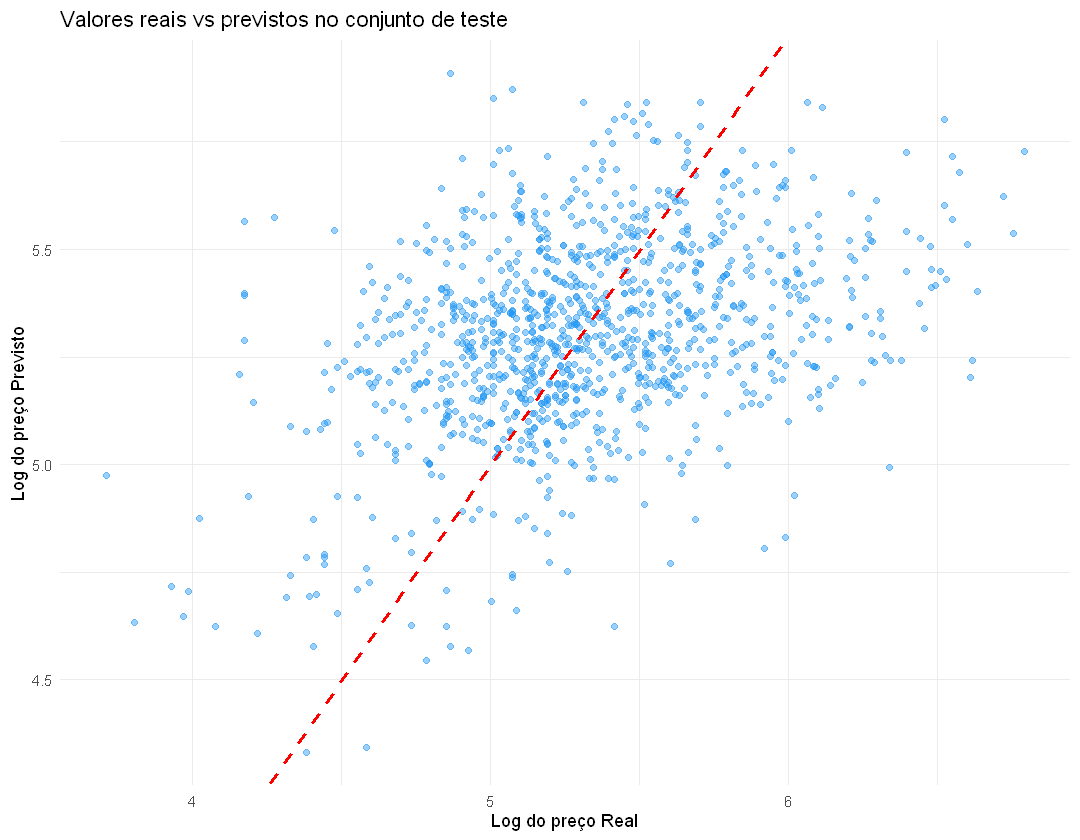

In [49]:
# Gráfico: Valores Reais vs Previstos do melhor modelo

previsoes_teste <- predict(melhor_modelo, newdata = df_test)

data.frame(
  real     = df_test$log_price,
  previsto = previsoes_teste
) %>%
  ggplot(aes(x = real, y = previsto)) +
  geom_point(alpha = 0.45, color = "#2196F3") +
  geom_abline(intercept = 0, slope = 1,
              color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Valores reais vs previstos no conjunto de teste",
    x     = "Log do preço Real",
    y     = "Log do preço Previsto"
  ) +
  theme_minimal()

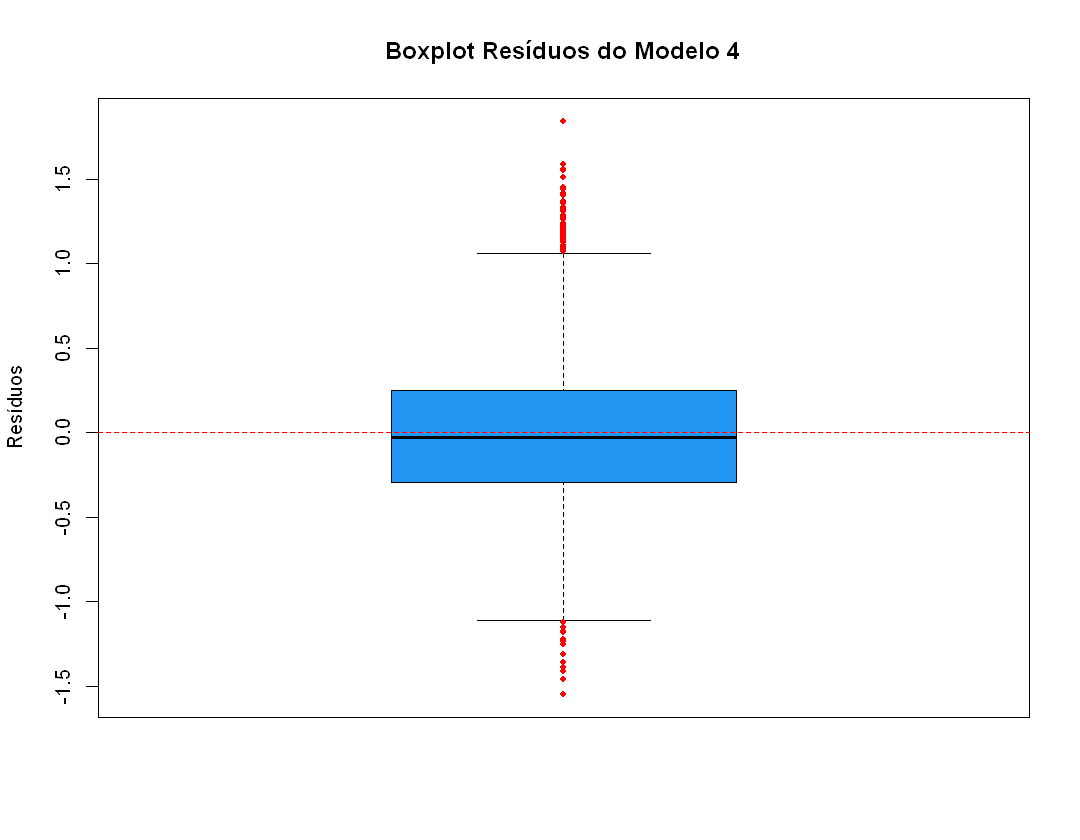

In [50]:
# Boxplot dos Resíduos para verificacao Outliers

par(bg = "white")
boxplot(melhor_modelo$residuals,
        main     = "Boxplot Resíduos do Modelo 4",
        ylab     = "Resíduos",
        col      = "#2196F3",
        border   = "black",
        outcol   = "red",
        outpch   = 20,
        horizontal = FALSE)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)

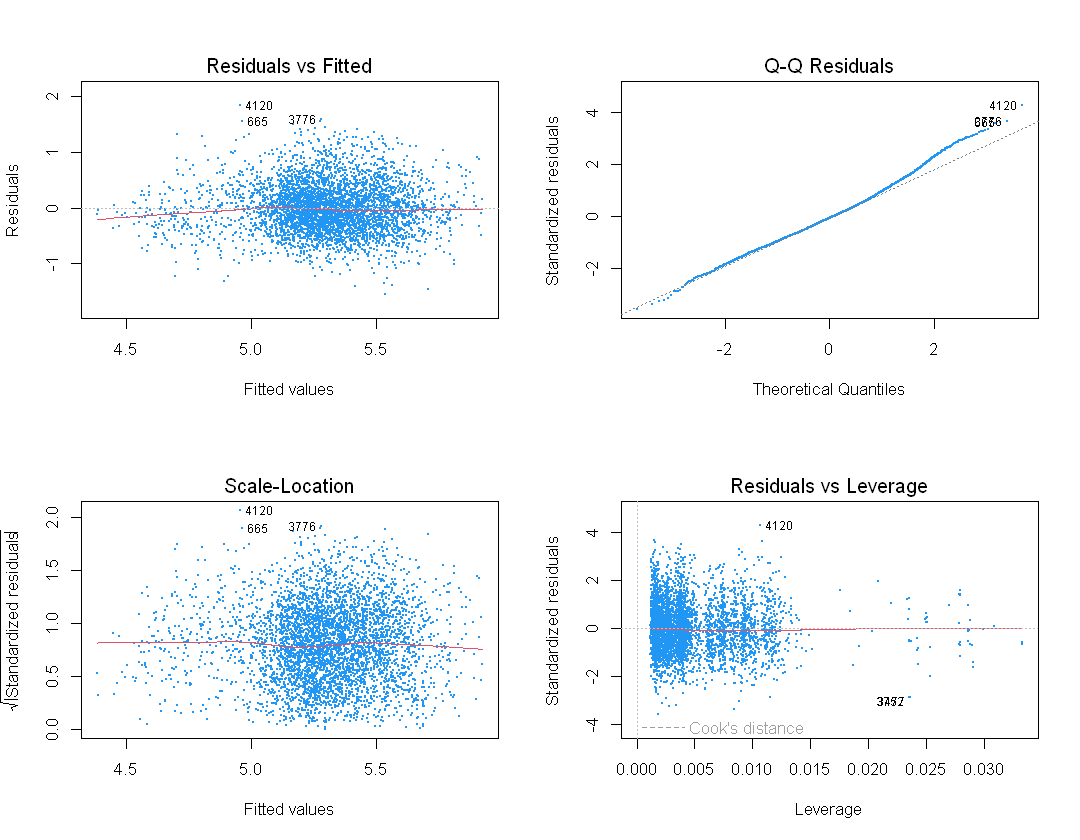

In [51]:
# Gráficos de resíduos do melhor modelo

par(mfrow = c(2, 2), bg = "white")
plot(melhor_modelo, col = "#2196F3", pch = 20, cex = 0.5)
par(mfrow = c(1, 1))

## Chow-Test 
O teste de Chow verifica se os coeficientes de um modelo de regressão são estatisticamente diferentes entre dois grupos. Ou seja, testa:

- H0: os coeficientes são iguais nos dois grupos. Um só modelo é suficiente
- H1: os coeficientes são diferentes. Dois modelos separados fazem mais sentido

Se rejeitarmos H0, há evidência estatística de que dividir os dados melhora o modelo.

O ponto de corte é a mediana do preço (log ~5.28). Dividimos em:

- Grupo 1: alojamentos baratos (log_price ≤ 5.28)
- Grupo 2: alojamentos caros (log_price > 5.28)


In [ ]:
# Teste de Chow

# Definir ponto de corte na mediana do log_price no treino
ponto_corte <- median(df_train$log_price)
cat("Ponto de corte (mediana log_price):", round(ponto_corte, 4), "\n")
cat("Equivalente em $:", round(exp(ponto_corte), 2), "\n\n")

# Criar variável de grupo no treino e teste
df_train$grupo <- ifelse(df_train$log_price <= ponto_corte, "barato", "caro")
df_test$grupo  <- ifelse(df_test$log_price  <= ponto_corte, "barato", "caro")

cat("Distribuição dos grupos no treino:\n")
print(table(df_train$grupo))

# Teste de Chow
chow <- sctest(log_price ~ neighbourhood + room_type +
                            minimum_nights + number_of_reviews_ltm +
                            availability_365,
               data = df_train,
               type = "Chow",
               point = floor(nrow(df_train) * 0.5))

print(chow)
cat("\nDecisão:", ifelse(chow$p.value < 0.05,
    "Rejeita H0 : dois modelos são estatisticamente justificados",
    "Não rejeita H0 : um modelo é suficiente"), "\n")

Ponto de corte (mediana log_price): 5.2883 


Equivalente em $: 198 

Distribuição dos grupos no treino:

barato   caro 
  2276   2205 

	Chow test

data:  log_price ~ neighbourhood + room_type + minimum_nights + number_of_reviews_ltm +     availability_365
F = 0.96147, p-value = 0.5094


Decisão: Não rejeita H0 : um modelo é suficiente 


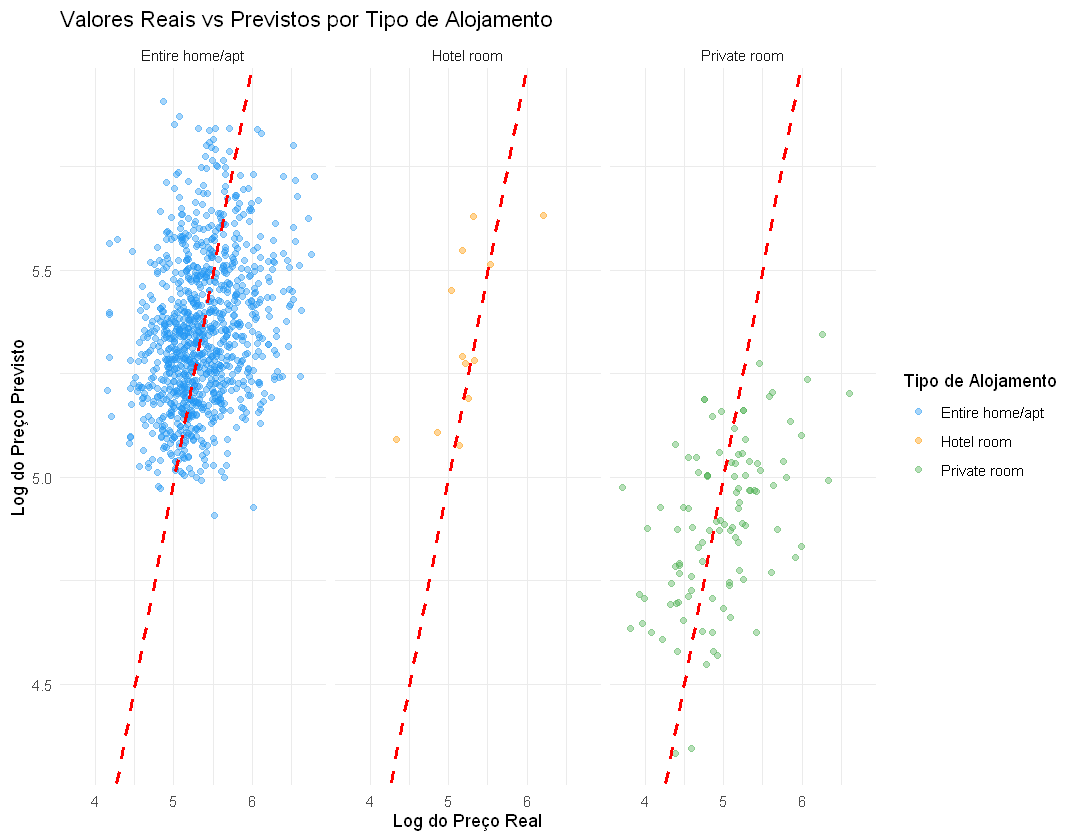

In [53]:
# Gráfico Real vs Previsto colorido por room_type
# Permite identificar se o modelo erra sistematicamente para algum tipo de quarto

previsoes_teste <- predict(melhor_modelo, newdata = df_test)

data.frame(
  real     = df_test$log_price,
  previsto = previsoes_teste,
  room_type = df_test$room_type
) %>%
  ggplot(aes(x = real, y = previsto, color = room_type)) +
  geom_point(alpha = 0.4, size = 1.5) +
  geom_abline(intercept = 0, slope = 1,
              color = "red", linetype = "dashed", linewidth = 1) +
  scale_color_manual(values = c("Entire home/apt" = "#2196F3",
                                "Hotel room"      = "#FF9800",
                                "Private room"    = "#4CAF50")) +
  labs(
    title  = "Valores Reais vs Previstos por Tipo de Alojamento",
    x      = "Log do Preço Real",
    y      = "Log do Preço Previsto",
    color  = "Tipo de Alojamento"
  ) +
  theme_minimal() +
  facet_wrap(~room_type)

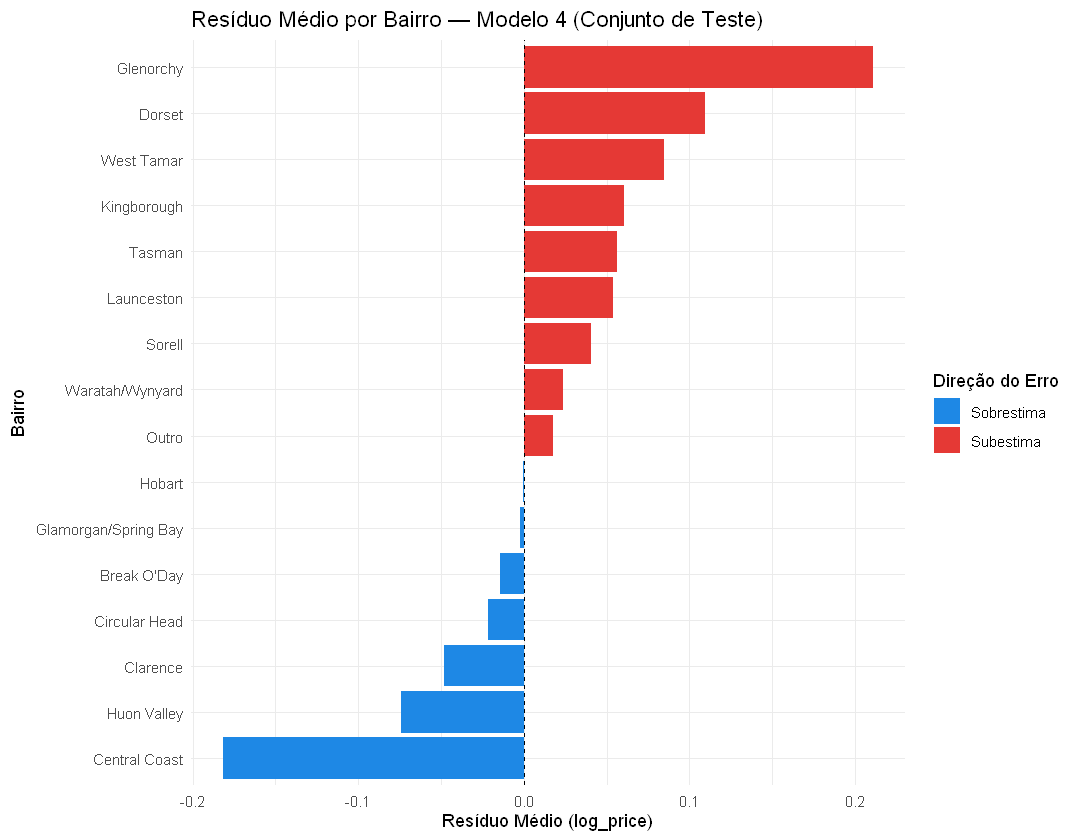

In [54]:
# Resíduos médios por bairro 
df_test$residuo_teste <- df_test$log_price - predict(melhor_modelo,
                                                      newdata = df_test)

df_test %>%
  group_by(neighbourhood) %>%
  summarise(
    residuo_medio = mean(residuo_teste),
    n = n()
  ) %>%
  ggplot(aes(x = reorder(neighbourhood, residuo_medio),
             y = residuo_medio,
             fill = residuo_medio > 0)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("TRUE" = "#E53935", "FALSE" = "#1E88E5"),
                    labels = c("TRUE" = "Subestima", "FALSE" = "Sobrestima")) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  labs(
    title = "Resíduo Médio por Bairro — Modelo 4 (Conjunto de Teste)",
    x     = "Bairro",
    y     = "Resíduo Médio (log_price)",
    fill  = "Direção do Erro"
  ) +
  theme_minimal()

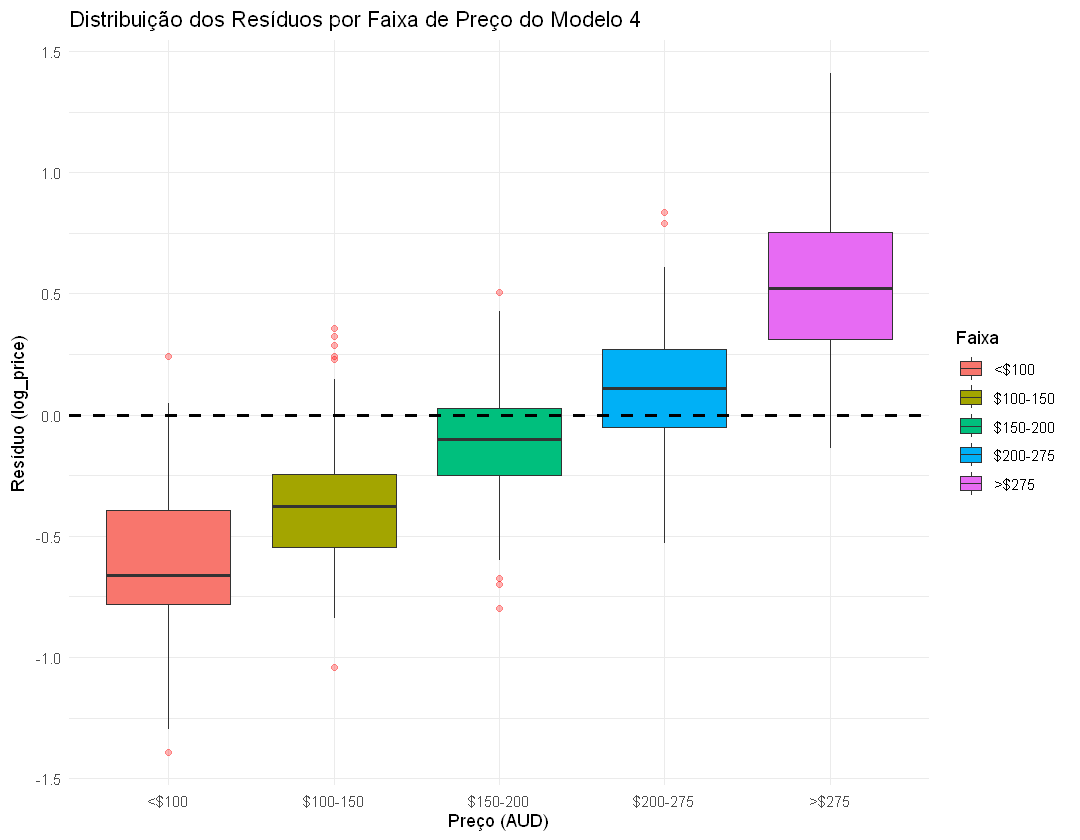

In [55]:
# Resíduos por faixa de preço

df_test$residuo   <- df_test$log_price - predict(melhor_modelo, newdata = df_test)
df_test$faixa_preco <- cut(exp(df_test$log_price),
                           breaks = c(0, 100, 150, 200, 275, Inf),
                           labels = c("<$100", "$100-150", "$150-200",
                                      "$200-275", ">$275"))

ggplot(df_test, aes(x = faixa_preco, y = residuo, fill = faixa_preco)) +
  geom_boxplot(outlier.alpha = 0.3, outlier.color = "red") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 1) +
  labs(
    title = "Distribuição dos Resíduos por Faixa de Preço do Modelo 4",
    x     = "Preço (AUD)",
    y     = "Resíduo (log_price)",
    fill  = "Faixa"
  ) +
  theme_minimal()